# **Optimalisasi JNE Express:**
## **Evaluasi SLA, Manajemen Risiko COD dan Modernisasi Tata Kelola Data**
---
Muhammad Fatkhan Nur Sholeh\
JCBDAAH - 006 | August 2026

# 1. Business Context

## 1.1 Background

Ledakan industri *e-commerce* di Indonesia membawa tantangan masif bagi operasional JNE. Ekspektasi pelanggan kini menuntut pengiriman yang serba cepat, murah, dan bisa dilacak secara real-time. Sayangnya, infrastruktur di lapangan seringkali kewalahan menghadapi lonjakan paket, yang memicu tumpukan barang dan pelanggaran batas waktu pengiriman (*Service Level Agreement / SLA Miss*).

Selain itu, tingginya tren pembayaran *Cash on Delivery* (COD) menimbulkan kerugian operasional akibat banyaknya paket yang ditolak pembeli dan harus diretur ke penjual (*Return to Sender / RTS*). Di sisi lain, database pengiriman juga dipenuhi anomali akibat sistem input manual oleh agen, yang menyebabkan ketidakkonsistenan penulisan layanan, kesalahan input berat paket yang memicu kebocoran pendapatan (*revenue leakage*), hingga mesin *scanner* yang *error*. Oleh karena itu, analisis mendalam dari hulu ke hilir perlu dilakukan untuk mengidentifikasi bottleneck distribusi dan membersihkan data tracking.  

## 1.2 Problem Statement

**Masalah Utama**: Tingginya biaya operasional (inefisiensi) yang disebabkan oleh pelanggaran ***SLA*** pengiriman, lonjakan paket ***retur (RTS)*** dari layanan ***COD***, dan kebocoran pendapatan akibat input data agen yang kotor.

**Pertanyaan Bisnis**:
- Cabang atau *sorting hub* mana yang paling sering menjadi titik *bottleneck* sehingga paket terlambat sampai ke konsumen (*SLA Miss*)?
- Bagaimana perbandingan tingkat **retur (RTS)** antara paket yang menggunakan metode pembayaran **COD** versus **Non-COD**?
- Seberapa besar estimasi kebocoran pendapatan akibat anomali input berat paket (***weight outliers***) yang lebih rendah dari berat aslinya?
- Layanan apa (**REG, YES, OKE**) yang paling sering mengalami ketidakkonsistenan penulisan di database, yang menyulitkan agregasi pelaporan?
- Seberapa banyak paket yang tercatat memiliki status "***Delivered***" (Sampai), namun *timestamp*-nya terjadi sebelum paket tersebut di-"*Pickup*" (Dijemput) oleh kurir (*Logical Error*)?
- Berapa persentase data pengirim (***Corporate/Individual***) yang kosong (***missing values***), yang menghambat tim Sales melakukan cross-selling? 

## 1.3 Goals

*Output* dari analisis data ini dirancang untuk merealisasikan beberapa target bisnis berikut::
- **Route & Hub Optimization**: Menemukan dan mengevaluasi cabang yang kinerjanya buruk, sehingga angka keterlambatan (SLA Miss) turun minimal 15%.
- **COD Risk Management**: Membangun blacklist atau aturan pengetatan layanan COD di daerah-daerah dengan rate RTS tertinggi untuk memangkas biaya retur.
- **Revenue Recovery**: Memperbaiki sistem input berat barang di level agen untuk menghentikan kebocoran omzet dari ongkos kirim yang tidak sesuai.
- **Data Reliability**: Memiliki pipeline data tracking yang bersih dari logical error, sehingga dashboard performa kurir dan SLA menampilkan angka yang valid.

# 2. Resources

## 2.1 Data Dictionary

Analisis ini menggunakan tiga tabel utama dengan total 300.000 baris fakta pengiriman. Berikut adalah *Dataset Dictionary*-nya: 


**A. Tabel `jne_customers.csv` (Dimensi Pelanggan/Pengirim)** 

| Nama Kolom | Deskripsi |
| :--- | :--- |
| `customer_id` | ID unik pelanggan/penjual. |
| `city` | Kota asal pelanggan. |
| `customer_type` | Tipe pelanggan (Corporate / Individual). |

**B. Tabel `jne_branches.csv` (Dimensi Cabang/Agen)** 

| Nama Kolom | Deskripsi |
| :--- | :--- |
| `branch_code` | Kode unik cabang atau hub JNE. |
| `branch_name` | Nama cabang. |
| `region` | Wilayah operasional (Jabodetabek, Jawa, Sumatera, dll). |

**C. Tabel `jne_shipments.csv` (Fakta Pengiriman)**

| Nama Kolom | Deskripsi |
| :--- | :--- |
| `awb_number` | Nomor Resi ( Airway Bill ) unik. |
| `sender_id` | ID pengirim. |
| `origin_branch` | Kode cabang tempat paket dikirim. |
| `dest_city` | Kota tujuan paket. |
| `service_type` | Jenis layanan. |
| `payment_type` | Metode pembayaran ongkir (Prepaid, COD). |
| `weight_kg` | Berat paket dalam Kilogram. |
| `pickup_date` | Tanggal dan jam paket dijemput/diserahkan ke agen. |
| `delivered_date` | Tanggal dan jam paket sampai ke penerima. |
| `status` | Status akhir pengiriman (Delivered, RTS, Lost, Damaged). |


## 2.2 Import Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import scipy.stats as st
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# 3. Data Understanding 

## 3.1 Load Dataset 

Untuk melakukan analisis lebih lanjut, ketiga dataset dibaca ke dalam DataFrame menggunakan fungsi `read_csv()` dari *pandas library*. Selanjutnya, lima baris teratas dan lima baris terbawah dari dataset tersebut diperiksa masing-masing menggunakan fungsi head() dan tail(), guna memperoleh pemahaman awal mengenai struktur dan isi dataset tersebut

In [59]:
df_branches = pd.read_csv(r'C:\Users\Ahan\Documents\Purwadhika\Modul 3\Capstone 3\Dataset\JNE\jne_branches.csv')
df_customers = pd.read_csv(r'C:\Users\Ahan\Documents\Purwadhika\Modul 3\Capstone 3\Dataset\JNE\jne_customers.csv')
df_shipments = pd.read_csv(r'C:\Users\Ahan\Documents\Purwadhika\Modul 3\Capstone 3\Dataset\JNE\jne_shipments.csv')

In [60]:
df_branches.sample(5)

,branch_code,branch_name,region
1,B-002,JNE Cabang Utama 2,Sumatera
134,B-135,JNE Cabang Utama 135,Jawa Barat
100,B-101,JNE Cabang Utama 101,Sumatera
69,B-070,JNE Cabang Utama 70,Jawa Barat
105,B-106,JNE Cabang Utama 106,Bali-Nusra


In [61]:
df_customers.sample(5)

,customer_id,city,customer_type
6191,CUST-06192,Makassar,Individual
8725,CUST-08726,Makassar,Individual
15690,CUST-15691,Yogyakarta,NaN
24946,CUST-24947,Denpasar,Corporate
632,CUST-00633,Palembang,Individual


In [62]:
df_shipments.head(5)

,awb_number,sender_id,origin_branch,dest_city,service_type,payment_type,weight_kg,pickup_date,delivered_date,status
0,JNE000000001,CUST-25624,B-035,Yogyakarta,Reguler,Prepaid,9.5,2023-05-12 17:00:00,2023-05-18 22:00:00,Delivered
1,JNE000000002,CUST-17057,B-054,Palembang,REG,COD,19.5,2023-05-02 15:00:00,2023-05-08 00:00:00,RTS
2,JNE000000003,CUST-27196,B-104,Yogyakarta,YES,Prepaid,14.8,2023-10-25 17:00:00,2023-10-27 19:00:00,Delivered
3,JNE000000004,CUST-15447,B-097,Medan,REG,Prepaid,16.3,2023-10-09 09:00:00,2023-10-14 19:00:00,Delivered
4,JNE000000005,CUST-20847,B-147,Surabaya,Yakin Esok Sampai,Prepaid,1.1,2023-08-22 09:00:00,2023-08-24 20:00:00,Delivered


## 3.2 Data Assessing

Jenis data setiap variabel diperiksa untuk memastikan bahwa semua kolom memiliki format yang sesuai untuk analisis. Langkah ini sangat penting untuk mencegah kesalahan selama pemrosesan data serta untuk memudahkan perhitungan statistik dan visualisasi yang akurat. Fungsi `info()` digunakan untuk memeriksa jenis data setiap variabel dalam kumpulan data tersebut.

In [63]:
df_branches.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   branch_code  150 non-null    str  
 1   branch_name  150 non-null    str  
 2   region       150 non-null    str  
dtypes: str(3)
memory usage: 8.6 KB


In [64]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customer_id    30000 non-null  str  
 1   city           30000 non-null  str  
 2   customer_type  25421 non-null  str  
dtypes: str(3)
memory usage: 1.4 MB


In [65]:
df_customers.isna().sum()

customer_id         0
city                0
customer_type    4579
dtype: int64

In [66]:
df_shipments.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   awb_number      300000 non-null  str    
 1   sender_id       300000 non-null  str    
 2   origin_branch   300000 non-null  str    
 3   dest_city       300000 non-null  str    
 4   service_type    300000 non-null  str    
 5   payment_type    300000 non-null  str    
 6   weight_kg       300000 non-null  float64
 7   pickup_date     300000 non-null  str    
 8   delivered_date  300000 non-null  str    
 9   status          300000 non-null  str    
dtypes: float64(1), str(9)
memory usage: 49.1 MB


In [67]:
display(df_shipments.describe(), df_branches.describe(), df_customers.describe())

,weight_kg
count,300000.000000
mean,23.845689
std,350.372839
min,-5.000000
25%,5.700000
50%,10.500000
75%,15.300000
max,9999.000000


,branch_code,branch_name,region
count,150,150,150
unique,150,150,8
top,B-001,JNE Cabang Utama 1,Jawa Barat
freq,1,1,28


,customer_id,city,customer_type
count,30000,30000,25421
unique,30000,10,2
top,CUST-00001,Yogyakarta,Individual
freq,1,3090,17896


In [68]:
description = pd.DataFrame({
    'type': df_branches.dtypes,
    'missing_values': df_branches.isna().sum(),
    'unique_values': df_branches.nunique(),
    'unique': df_branches.apply(lambda x: x.unique())
})

description

,type,missing_values,unique_values,unique
branch_code,str,0,150,"[B-001, B-002, B-003, B-004, B-005, B-006, B-0..."
branch_name,str,0,150,"[JNE Cabang Utama 1, JNE Cabang Utama 2, JNE C..."
region,str,0,8,"[Sumatera, Kalimantan, Jabodetabek, Jawa Barat..."


In [69]:
description = pd.DataFrame({
    'type': df_customers.dtypes,
    'missing_values': df_customers.isna().sum(),
    'unique_values': df_customers.nunique(),
    'unique': df_customers.apply(lambda x: x.unique())
})

description

,type,missing_values,unique_values,unique
customer_id,str,0,30000,"[CUST-00001, CUST-00002, CUST-00003, CUST-0000..."
city,str,0,10,"[Makassar, Denpasar, Medan, Balikpapan, Bandun..."
customer_type,str,4579,2,"[Individual, nan, Corporate]"


In [70]:
description = pd.DataFrame({
    'type': df_shipments.dtypes,
    'missing_values': df_shipments.isna().sum(),
    'unique_values': df_shipments.nunique(),
    'unique': df_shipments.apply(lambda x: x.unique())
})

description

,type,missing_values,unique_values,unique
awb_number,str,0,300000,"[JNE000000001, JNE000000002, JNE000000003, JNE..."
sender_id,str,0,29999,"[CUST-25624, CUST-17057, CUST-27196, CUST-1544..."
origin_branch,str,0,150,"[B-035, B-054, B-104, B-097, B-147, B-131, B-0..."
dest_city,str,0,10,"[Yogyakarta, Palembang, Medan, Surabaya, Balik..."
service_type,str,0,9,"[Reguler, REG, YES, Yakin Esok Sampai, reg, OK..."
payment_type,str,0,2,"[Prepaid, COD]"
weight_kg,float64,0,195,"[9.5, 19.5, 14.8, 16.3, 1.1, 8.9, 16.4, 14.7, ..."
pickup_date,str,0,2160,"[2023-05-12 17:00:00, 2023-05-02 15:00:00, 202..."
delivered_date,str,0,4282,"[2023-05-18 22:00:00, 2023-05-08 00:00:00, 202..."
status,str,0,4,"[Delivered, RTS, Lost, Damaged]"


In [ ]:
# Mencari data pelanggan yang TIDAK ADA di dalam kolom sender_id pada tabel shipments
inactive_customer = df_customers[~df_customers['customer_id'].isin(df_shipments['sender_id'])]
display(inactive_customer)

,customer_id,city,customer_type
11430,CUST-11431,Semarang,NaN


Terlihat kita memiliki data customer sebanyak 30000 di `df_customer` tapi hanya terdapat 29999 customer di `df_shipments`, jadi ada 1 customer yang tidak pernah melakukan transaksi

In [ ]:
df_shipments['service_type'].value_counts()


service_type
REG                      89984
YES                      44981
OKE                      30140
oke                      30061
Reguler                  29943
reg                      29908
Yakin Esok Sampai        15099
yes                      14960
Ongkos Kirim Ekonomis    14924
Name: count, dtype: int64

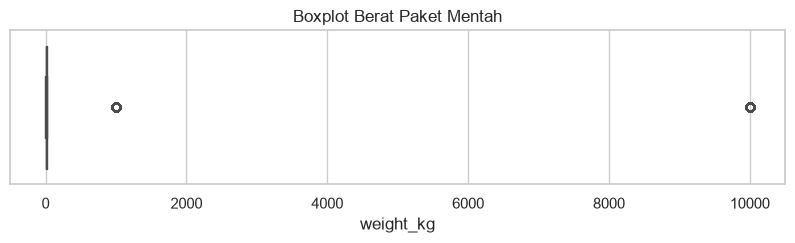

In [73]:
plt.figure(figsize=(10, 2))
sns.boxplot(data=df_shipments, x='weight_kg')
plt.title('Boxplot Berat Paket Mentah')
plt.show()

In [ ]:
# 1. Memfilter HANYA data yang menyalahi aturan ( 0 kg atau > 50 kg)
df_anomali = df_shipments[(df_shipments['weight_kg'] <= 0) | (df_shipments['weight_kg'] > 50)]

print(f"Total baris data anomali: {len(df_anomali)} bari")
print("--- ANOMALI ---")
print(df_anomali['weight_kg'].value_counts())

Total baris data anomali: 1500 bari
--- ANOMALI ---
weight_kg
-1.5       401
-5.0       368
 9999.0    366
 999.0     365
Name: count, dtype: int64


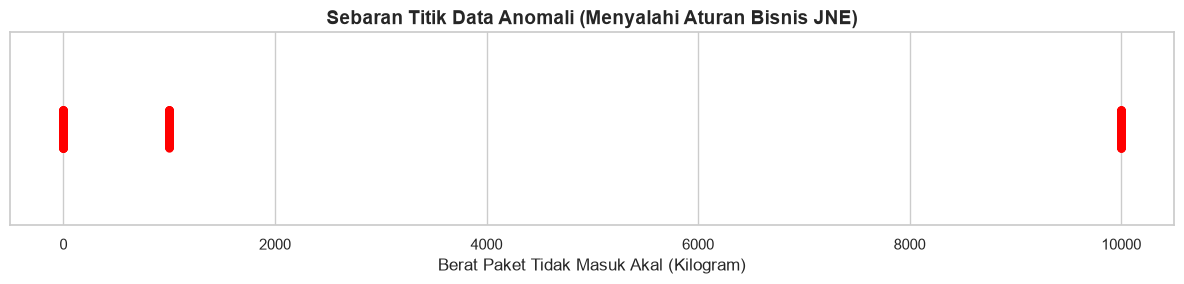

In [ ]:
plt.figure(figsize=(12, 3))
sns.stripplot(
    data=df_anomali, 
    x='weight_kg', 
    color='red', 
    alpha=0.6, 
    jitter=True, 
    size=6
)

plt.title('Sebaran Titik Data Anomali (Menyalahi Aturan Bisnis JNE)', fontsize=14, fontweight='bold')
plt.xlabel('Berat Paket Tidak Masuk Akal (Kilogram)', fontsize=12)
plt.tight_layout()
plt.show()

Terlihat bahwa ada data anomali yang menyalahi aturan bisnis JNE, asumsi karena sistem tidak rigid (bisa input nilai minus dan lebih dari 50kg) yang mengakibatkan karyawan bisa salah input

## 3.3 Cek Duplikasi
Di industri logistik, satu nomor resi (`awb_number`) mutlak harus unik untuk satu kali pengiriman. Begitu juga dengan ID Pelanggan (`customer_id`). Jika ada data yang tercatat dua kali (duplikat) di database, perhitungan total paket terlambat atau total pendapatan perusahaan nantinya bisa dihitung ganda (double-counting), yang mana sangat fatal untuk pelaporan bisnis.

In [76]:
# 1. Mengecek baris yang sepenuhnya duplikat di ketiga dataset
print("Total duplikat di df_branches  : ", df_branches.duplicated().sum())
print("Total duplikat di df_customers : ", df_customers.duplicated().sum())
print("Total duplikat di df_shipments : ", df_shipments.duplicated().sum())

# 2. Pengecekan spesifik: Memastikan tidak ada nomor resi (awb_number), nomor pelanggan (customer_id) dan kode cabang (branch_code) yang ganda
print("Total resi (awb_number) ganda  : ", df_shipments.duplicated(subset=['awb_number']).sum())
print("Total pelanggan (customer_id) ganda  : ", df_customers.duplicated(subset=['customer_id']).sum())
print("Total cabang (branch_code) ganda  : ", df_branches.duplicated(subset=['branch_code']).sum())

Total duplikat di df_branches  :  0
Total duplikat di df_customers :  0
Total duplikat di df_shipments :  0
Total resi (awb_number) ganda  :  0
Total pelanggan (customer_id) ganda  :  0
Total cabang (branch_code) ganda  :  0


Data sudah aman dari duplikasi dan bisa dilanjutkan proses selanjutnya

## 3.4 Data Assessing Summary

Setelah melihat data di atas menggunakan `.info()` dan `.describe()`, berikut adalah ringkasan temuan (diagnosis) dari ketiga dataset yang akan ditindaklanjuti pada tahap *Data Cleaning*:

**A. Tabel Cabang (`df_branches`)**
* **Struktur data aman:** Seluruh 150 baris terisi penuh (*non-null*) dan tipe datanya sudah sesuai berupa teks/string.

**B. Tabel Pelanggan (`df_customers`)**
* **Data kosong (*missing values*):** Ditemukan data kosong pada kolom `customer_type`. Dari total 30.000 baris, hanya 25.421 data yang terisi, yang berarti ada sekitar 4.500+ baris data tipe pelanggan yang hilang dan perlu ditangani.

**C. Tabel Pengiriman (`df_shipments`)**
* **Kesalahan tipe data:** Kolom `pickup_date` dan `delivered_date` saat ini terdeteksi sebagai *string/object* (teks), yang mana harus diubah ke format `datetime` agar perhitungan durasi keterlambatan pengiriman dapat dilakukan.
* **Anomali berat minimum:** Terdapat paket yang tercatat memiliki berat **-5.0 kg**. Bobot minus adalah sebuah kemustahilan dan murni merupakan kesalahan *input* sistem.
* **Anomali berat maksimum (*outliers*):** Terdapat paket dengan berat mencapai **9999.0 kg** (hampir 10 ton). Mengingat ini adalah jasa ekspedisi standar, angka ini sangat patut dicurigai sebagai *typo* (salah ketik) atau anomali *input* agen.
* **Ketidakkonsistenan kategori layanan:** Terdapat 9 variasi yang harusnya hanya 3 penulisan pada kolom `service_type` (seperti 'Reguler', 'reg', 'Yakin Esok Sampai') akibat *input* manual agen. Data ini harus distandarisasi menjadi format baku (REG, YES, OKE) agar proses agregasi laporan dapat berjalan lancar.
* **Kesimpulan Cek Duplikasi:** Berdasarkan hasil pengecekan di atas, integritas baris data kita terbukti sangat solid. Ketiga dataset (cabang, pelanggan, dan pengiriman) terbukti 100% bersih dari data ganda (duplikat). Hal yang paling krusial, seluruh nomor resi (`awb_number`) juga terbukti unik, yang berarti tidak ada indikasi transaksi pengiriman yang tercatat dua kali di dalam sistem. Kita aman untuk melangkah ke tahap selanjutnya!

# 4. Data Cleaning

Setelah kita melakukan *Data Assessing* dan *Duplicate Check*, kita bisa melanjutkan untuk *cleaning* data sebelum kita *merge* dan melakukan analisis

## 4.1 Cleaning `df_customer` Missing Values

In [77]:
# 1. Mengisi nilai kosong (NaN) di kolom customer_type dengan 'Unknown'
df_customers['customer_type'] = df_customers['customer_type'].fillna('Unknown')

# 2. Validasi hasil pembersihan
print("Jumlah missing values pada df_customers setelah dibersihkan:")
print(df_customers.isna().sum())

# 3. Mengecek distribusi datanya sekarang
print("\nDistribusi tipe pelanggan saat ini:")
print(df_customers['customer_type'].value_counts())

Jumlah missing values pada df_customers setelah dibersihkan:
customer_id      0
city             0
customer_type    0
dtype: int64

Distribusi tipe pelanggan saat ini:
customer_type
Individual    17896
Corporate      7525
Unknown        4579
Name: count, dtype: int64


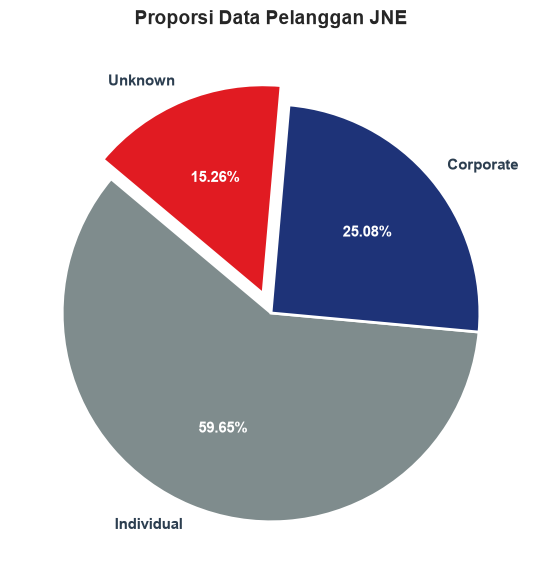

In [78]:
# 1. Menghitung jumlah per kategori
cust_counts = df_customers['customer_type'].value_counts()

# 2. Setup Warna Identitas JNE
colors = ['#E11B22' if label == 'Unknown' else '#1E3378' if label == 'Corporate' else '#7F8C8D' for label in cust_counts.index]
explode = [0.1 if label == 'Unknown' else 0 for label in cust_counts.index]

# 3. Membuat Pie Chart dan Menangkap Elemen Teksnya
plt.figure(figsize=(9, 6))

patches, texts, autotexts = plt.pie(
    cust_counts, 
    labels=cust_counts.index, 
    autopct='%1.2f%%', 
    startangle=140,    
    colors=colors, 
    explode=explode,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# 4. MENGATUR WARNA TEKS SECARA TERPISAH (SOLUSI)
# Teks nama label di luar irisan -> Gelap/Hitam
for t in texts:
    t.set_color('#2c3e50')
    t.set_fontsize(11)
    t.set_fontweight('bold')

# Teks angka persentase di dalam irisan -> Putih
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(11)
    at.set_fontweight('bold')


# 5. Judul
plt.title('Proporsi Data Pelanggan JNE', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# Menampilkan grafik
plt.show()

Di sini kita merubah data kosong (*null/NaN*) pada kolom `customer_type` menjadi kategori **`'Unknown'`** agar data tersebut tidak hilang dan tetap bisa dianalisis. 

Menggunakan label `'Unknown'` adalah pendekatan *best practice* dibandingkan menebaknya dengan mengisi nilai modus/mean/median. Jika kita sembarangan memaksa mengisi 4.500+ pelanggan tak dikenal tersebut dengan label 'Individual' atau 'Corporate', kita berisiko menyesatkan strategi *cross-selling* tim Sales JNE di masa depan.

Tim Sales JNE kehilangan profil dari 15.26% pelanggannya. Jika data ini lengkap, tim B2B Sales bisa memanfaatkannya untuk mem-*follow up* pengirim individu berskala besar agar di-*upgrade* menjadi akun *Corporate (Cross-selling)*

---

## 4.2 Merubah *data type* `pickup_date` dan `delivered_date` ke format datetime

In [ ]:
# Mengubah kolom pickup_date dan delivered_date menjadi tipe data datetime
df_shipments['pickup_date'] = pd.to_datetime(df_shipments['pickup_date'])
df_shipments['delivered_date'] = pd.to_datetime(df_shipments['delivered_date'])

print("Tipe data setelah konversi:")
print(df_shipments[['pickup_date', 'delivered_date']].dtypes)

Tipe data setelah konversi:
pickup_date       datetime64[us]
delivered_date    datetime64[us]
dtype: object


Pada tahap ini, kita mengubah tipe data pada kolom `pickup_date` dan `delivered_date` dari yang awalnya berupa *string* menjadi format waktu (*datetime*).

Langkah ini mutlak diperlukan karena salah satu target utama analisis bisnis kita adalah mengevaluasi keterlambatan pengiriman (*SLA Miss*). Dengan menggunakan format `datetime`, sekarang kita bisa mencari selisih waktu/durasi antara waktu paket dijemput dan waktu paket sampai di tangan penerima.

---

## 4.3 Merubah penulisan di kolom `service_type` sesuai dengan standar bisnis  

In [ ]:
# 1. Membuat kolom BARU ('service_type_clean') agar data asli/kotor tetap tersimpan sebagai barang bukti
df_shipments['service_type_clean'] = df_shipments['service_type'].str.upper().str.strip()

# 2. Membuat dictionary untuk standarisasi
mapping_layanan = {
    'REGULER': 'REG',
    'YAKIN ESOK SAMPAI': 'YES',
    'ONGKOS KIRIM EKONOMIS': 'OKE'
}

# 3. Mengaplikasikan perubahan HANYA pada kolom baru (service_type_clean)
df_shipments['service_type_clean'] = df_shipments['service_type_clean'].replace(mapping_layanan)

# 4. Membandingkan kolom kotor dan kolom bersih bersisihan
print("Perbandingan Data Asli vs Data Bersih:")
print(df_shipments[['service_type', 'service_type_clean']].sample(10))

Perbandingan Data Asli vs Data Bersih:
                 service_type service_type_clean
11218                     reg                REG
73373                 Reguler                REG
44260                     REG                REG
154262                    YES                YES
267971                    REG                REG
93129                     REG                REG
217982                    oke                OKE
179326  Ongkos Kirim Ekonomis                OKE
38698                     REG                REG
145867                    YES                YES


In [81]:
# 1. Menampilkan perbandingan jumlah sebelum vs sesudah
print("--- SEBELUM DIBERSIHKAN (Teks Asli Agen) ---")
# Hanya mengambil data yang kebetulan diketik benar (REG, YES, OKE) sejak awal
print(df_shipments['service_type'][df_shipments['service_type'].isin(['REG', 'YES', 'OKE'])].value_counts())

print("\n--- SESUDAH DIBERSIHKAN (Standardisasi Sistem) ---")
print(df_shipments['service_type_clean'].value_counts())

# 2. Menghitung total kesalahan ketik (Typo/Inkonsistensi)
total_error = (df_shipments['service_type'] != df_shipments['service_type_clean']).sum()
persentase_error = (total_error / len(df_shipments)) * 100

print(f"\n[KESIMPULAN BISNIS]")
print(f"Ditemukan {total_error} baris data pengiriman ({persentase_error:.2f}%) yang mengalami salah ketik atau inkonsistensi penamaan layanan oleh agen.")

--- SEBELUM DIBERSIHKAN (Teks Asli Agen) ---
service_type
REG    89984
YES    44981
OKE    30140
Name: count, dtype: int64

--- SESUDAH DIBERSIHKAN (Standardisasi Sistem) ---
service_type_clean
REG    149835
OKE     75125
YES     75040
Name: count, dtype: int64

[KESIMPULAN BISNIS]
Ditemukan 134895 baris data pengiriman (44.96%) yang mengalami salah ketik atau inkonsistensi penamaan layanan oleh agen.


In [82]:
# 1. Menandai baris mana saja yang mengalami error (True jika typo, False jika benar)
df_shipments['is_typo'] = df_shipments['service_type'] != df_shipments['service_type_clean']

# 2. Menghitung persentase error secara keseluruhan
total_error = df_shipments['is_typo'].sum()
persentase_error = (total_error / len(df_shipments)) * 100

print(f"--- KESIMPULAN ERROR KESELURUHAN ---")
print(f"Total Typo: {total_error} baris ({persentase_error:.2f}% dari total data)\n")

# 3. Menghitung rincian error PER LAYANAN (REG, YES, OKE)
print("--- RINCIAN ERROR PER TIPE LAYANAN ---")
# Menggunakan groupby untuk menghitung total transaksi (count) dan total typo (sum dari boolean)
error_per_service = df_shipments.groupby('service_type_clean')['is_typo'].agg(['count', 'sum']).reset_index()

# Mengubah nama kolom agar representatif
error_per_service.columns = ['Layanan', 'Total_Transaksi', 'Total_Typo']

# Menghitung persentase per layanan
error_per_service['Persentase_Error'] = (error_per_service['Total_Typo'] / error_per_service['Total_Transaksi']) * 100

# Menampilkan hasil dengan format print yang rapi untuk laporan
for index, row in error_per_service.iterrows():
    print(f"Layanan {row['Layanan']:<3} : {row['Total_Typo']:>6} typo dari {row['Total_Transaksi']:>7} transaksi ({row['Persentase_Error']:.2f}%)")

# Didrop karena sudah tidak digunakan lagi
df_shipments = df_shipments.drop(columns=['is_typo'])

--- KESIMPULAN ERROR KESELURUHAN ---
Total Typo: 134895 baris (44.96% dari total data)

--- RINCIAN ERROR PER TIPE LAYANAN ---
Layanan OKE :  44985 typo dari   75125 transaksi (59.88%)
Layanan REG :  59851 typo dari  149835 transaksi (39.94%)
Layanan YES :  30059 typo dari   75040 transaksi (40.06%)


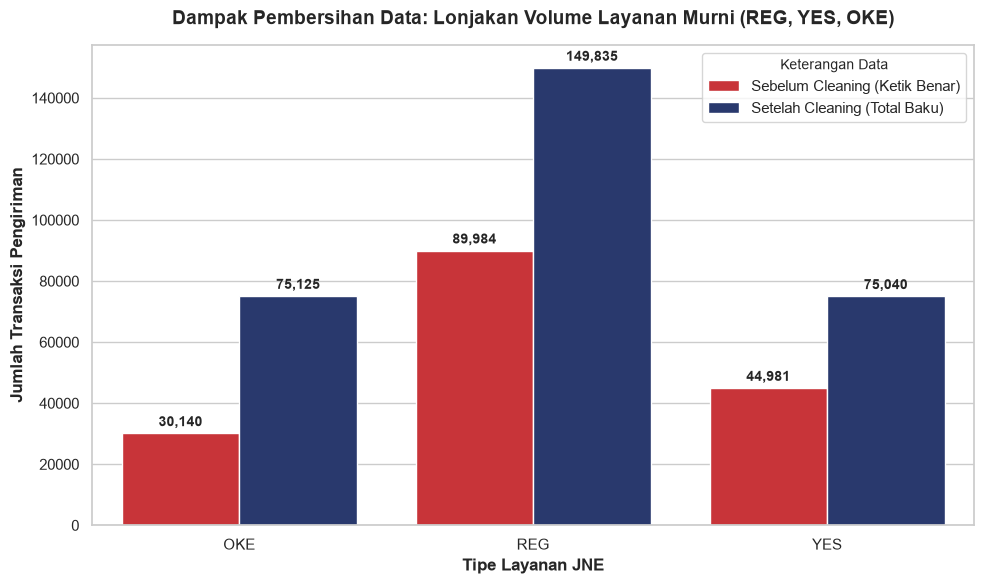

In [ ]:
# 1. Mengatur style grafik agar bersih dan profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Menyiapkan data untuk visualisasi perbandingan
# Mengambil jumlah data baku awal (teks REG, YES, OKE yang sudah benar dari awal)
awal_correct = df_shipments['service_type'][df_shipments['service_type'].isin(['REG', 'YES', 'OKE'])].value_counts()
# Mengambil jumlah total setelah disatukan
setelah_clean = df_shipments['service_type_clean'].value_counts()

# Menggabungkan ke dalam DataFrame khusus plot
df_plot = pd.DataFrame({
    'Sebelum Cleaning (Ketik Benar)': awal_correct,
    'Setelah Cleaning (Total Baku)': setelah_clean
}).reset_index()

df_plot.rename(columns={'index': 'Layanan'}, inplace=True)

# Mengubah bentuk data ke format long-format untuk Seaborn
df_melted = pd.melt(df_plot, id_vars=['Layanan'], var_name='Status Data', value_name='Jumlah Transaksi')

# 3. Membuat Grouped Bar Chart
ax = sns.barplot(
    data=df_melted, 
    x='Layanan', 
    y='Jumlah Transaksi', 
    hue='Status Data', 
    palette=['#E11B22', '#1E3378'] # Merah untuk awal, Hijau untuk setelah clean
)

# 4. Menambahkan label angka di atas setiap batang grafik
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 3),
                    textcoords='offset points')

# 5. Kustomisasi Judul dan Label
plt.title('Dampak Pembersihan Data: Lonjakan Volume Layanan Murni (REG, YES, OKE)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipe Layanan JNE', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Transaksi Pengiriman', fontsize=12, fontweight='bold')
plt.legend(title='Keterangan Data', title_fontsize='10', loc='upper right')
plt.tight_layout()

# Menampilkan grafik
plt.show()


Pada tahap ini, kita melakukan evaluasi terhadap kolom `service_type` sebelum dan sesudah proses pembersihan. Ditemukan adanya variasi penulisan nama layanan akibat *input* manual oleh agen di lapangan (seperti penulisan `'Reguler'`, `'reg'`, `'Yakin Esok Sampai'`, hingga `'ONGKOS KIRIM EKONOMIS'`).

Alih-alih menimpa data asli, kita menerapkan pendekatan *Non-Destructive Transformation* dengan membuat kolom baru `service_type_clean`. Langkah ini diambil agar jejak data mentah (*audit trail*) tetap tersimpan sebagai bukti operasional.

**Key Insights & Rekomendasi Bisnis:**
1. **Implikasi Sistem:** Tingginya tingkat inkonsistensi penulisan ini membuktikan bahwa agen di gerai/agen fisik masih diberikan keleluasaan melakukan *free-text input* pada sistem POS (*Point of Sale*).
2. **Dampak Operasional:** Tanpa proses *cleaning*, agregasi volume pengiriman per layanan di *dashboard* manajemen akan terpecah-pecah dan menghasilkan pelaporan yang menyesatkan (*misleading*).

Berdasarkan hasil eksplorasi awal, ditemukan 9 variasi penulisan nama layanan akibat ketidakkonsistenan *input* manual oleh agen (misalnya: 'reg', 'Reguler', hingga 'Yakin Esok Sampai').Di sini, kita menstandarisasinya menggunakan metode *dictionary mapping* untuk memaksanya menjadi 3 kategori baku JNE: **REG, YES, dan OKE**.

Pembersihan ini sangat penting dilakukan. Tanpa standarisasi, agregasi data pada tahap pelaporan atau pembuatan *dashboard* nantinya akan terpecah-pecah dan berantakan. Kini, kita dapat memantau volume dan membandingkan performa SLA pengiriman untuk tiap-tiap layanan dengan akurat.

---

## 4.4 Pemisahan Anomali Berat Paket (Weight Outliers)

Di sini tidak menggunakan perhitungan dengan IQR karena JNE sudah mempunyai aturan bisnis tersendiri yaitu 0kg < `weight_kg` > 50kg

In [84]:
# Flagging Anomali Berat Paket (Batas rasional: 0.1 kg - 50 kg) sesuai dengan Business Rule JNE
kondisi_berat = (df_shipments['weight_kg'] <= 0) | (df_shipments['weight_kg'] > 50)
df_shipments['weight_status'] = np.where(kondisi_berat, 'Anomaly', 'Normal')

# Hasilnya
print(f"Total Master Data (Menyimpan Barang Bukti) : {len(df_shipments)} baris")
print(f"  > Total Anomali Berat Paket              : {sum(df_shipments['weight_status'] == 'Anomaly')} baris")
print(f"  > Persentase Anomali Berat Paket         : {sum(df_shipments['weight_status'] == 'Anomaly') / len(df_shipments) * 100:.2f}%")

Total Master Data (Menyimpan Barang Bukti) : 300000 baris
  > Total Anomali Berat Paket              : 1500 baris
  > Persentase Anomali Berat Paket         : 0.50%


Dalam mendeteksi anomali berat barang, analisis ini **tidak menggunakan pendekatan statistik murni** (seperti *Interquartile Range* / IQR). Mengingat mayoritas pengiriman JNE adalah barang ringan (1-2 kg), metode IQR berpotensi salah mengklasifikasikan paket besar yang sah (misalnya 15 kg) sebagai *outlier*. 

Oleh karena itu, penyaringan dilakukan secara pragmatis menggunakan ***Business Rules* JNE**, di mana batas berat paket berada di rentang **0.1 kg hingga 50 kg**.

Berdasarkan hasil *flagging*, ditemukan **1.500 transaksi** yang mengalami anomali berat (di bawah 0 kg atau di atas 50kg). Kasus seperti ini umumnya dipicu oleh *human error* (salah ketik) saat agen melakukan *input* manual di gerai ujung tombak. Data anomali ini HANYA diberi label (*flagging*) dan tetap disimpan di dalam dataset (`df_shipments`) untuk keperluan audit pada tahap analisis ***Revenue Recovery* (Potensi Kebocoran Omzet)** akibat selisih tarif.

---

## 4.5 Pembersihan Logical Error (Validasi Waktu)

In [85]:
# Flagging Logical Error Tanggal (Waktu sampai mendahului waktu jemput)
kondisi_waktu = df_shipments['delivered_date'] < df_shipments['pickup_date']
df_shipments['time_status'] = np.where(kondisi_waktu, 'Error', 'Valid')

# Hasil
print(f"Total Master Data (Menyimpan Barang Bukti) : {len(df_shipments)} baris")
print(f"  > Total Logical Error Waktu              : {sum(df_shipments['time_status'] == 'Error')} baris")
print(f"  > Persentase Logical Error Waktu         : {sum(df_shipments['time_status'] == 'Error') / len(df_shipments) * 100:.2f}%")

Total Master Data (Menyimpan Barang Bukti) : 300000 baris
  > Total Logical Error Waktu              : 7473 baris
  > Persentase Logical Error Waktu         : 2.49%


Langkah berikutnya yaitu memvalidasi integritas rentang waktu pengiriman. Berdasarkan logika operasional yang mutlak, tidak mungkin sebuah paket berstatus diterima oleh pelanggan (`delivered_date`) *mendahului* waktu paket tersebut diproses oleh agen (`pickup_date`).

Hasil validasi menunjukkan adanya **7.473 transaksi** yang mengalami "penjelajahan waktu" (*time-travel anomaly*). Kegagalan sinkronisasi waktu ini sangat mungkin disebabkan oleh *glitch* pada sistem internal atau *error* saat kurir melakukan pemindaian menggunakan mesin *barcode scanner*. 

Baris data cacat waktu ini diberi *flagging* khusus. Menyingkirkannya dari tabel analisis utama sangatlah krusial; karena jika dibiarkan, selisih waktu akan bernilai negatif dan merusak seluruh kalkulasi batas waktu pengiriman (*SLA Miss*) di tahap evaluasi performa. Selain itu, temuan ini akan menjadi masukan berharga untuk perbaikan infrastruktur **Data Governance** JNE.

---

## 4.6 Membuat variabel yang bersih untuk keperluan EDA

In [86]:
# Membuat "Tabel Analitik" (df_analytical) khusus untuk EDA
# Memfilter HANYA data yang Normal dan Valid
df_analytical = df_shipments[(df_shipments['weight_status'] == 'Normal') & (df_shipments['time_status'] == 'Valid')].copy()

# Hasil
print("--- HASIL FINAL DATA CLEANING ---")
print(f"Total Master Data (Menyimpan Barang Bukti) : {len(df_shipments)} baris")
print(f"  > Total Anomali Berat Paket              : {sum(df_shipments['weight_status'] == 'Anomaly')} baris")
print(f"  > Total Logical Error Waktu              : {sum(df_shipments['time_status'] == 'Error')} baris")
print("-" * 50)
print(f"Total Data Bersih (df_analytical)          : {len(df_analytical)} baris siap analisis!")

--- HASIL FINAL DATA CLEANING ---
Total Master Data (Menyimpan Barang Bukti) : 300000 baris
  > Total Anomali Berat Paket              : 1500 baris
  > Total Logical Error Waktu              : 7473 baris
--------------------------------------------------
Total Data Bersih (df_analytical)          : 291079 baris siap analisis!


Setelah memetakan dan mengkarantina data yang terjangkit anomali berat dan *logical Error* pengiriman, langkah penutup dalam fase *Data Cleaning* ini adalah mengekstrak seluruh transaksi yang 100% sehat ke dalam satu tabel khusus (`df_analytical`).

Proses penyaringan ketat ini dilakukan menggunakan operator logika gabungan. Sistem secara otomatis membuang transaksi yang memiliki salah satu atau kedua "penyakit" tersebut sekaligus (terbukti dari selisih pemotongan, terdapat 52 paket yang mengalami cacat ganda: berat anomali sekaligus waktu yang terbalik). 

Hasilnya, dari 300.000 transaksi awal, kita berhasil mengamankan **291.079 baris data pengiriman murni**.

Tabel `df_analytical` ini kini bertindak sebagai *Golden Record* atau *Single Source of Truth* yang siap digunakan. Memastikan kebersihan data di tahap ini adalah jaminan mutlak agar perhitungan metrik performa batas waktu (SLA) dan analisis tren operasional di tahap *Exploratory Data Analysis* (EDA) nanti benar-benar presisi, bebas dari bias anomali, dan dapat diandalkan sebagai landasan keputusan strategis manajemen JNE.

# 5. EDA

## 5.1 Penggabungan Data (Data Merging)
Untuk dapat menganalisis performa cabang dan karakteristik pelanggan, kita menggabungkan tabel pengiriman bersih (`df_shipments` / `df_analytical`) dengan tabel cabang (`df_branches`) dan tabel pelanggan (`df_customers`) menggunakan metode *INNER JOIN*.

In [87]:
# 1. Menggabungkan Data Pengiriman Bersih dengan df_branches
df_master = pd.merge(df_analytical, df_branches, left_on='origin_branch', right_on='branch_code', how='inner')

# 2. Menggabungkan hasilnya dengan df_customers
df_master = pd.merge(df_master, df_customers, left_on='sender_id', right_on='customer_id', how='inner')

# 3. Membuang kolom yang tidak diperlukan
df_master = df_master.drop(columns=['service_type', 'branch_code', 'customer_id', 'weight_status', 'time_status'])

# 4. Cek hasil akhir tabel raksasa kita
print("--- STATUS MASTER DATA UNTUK EDA ---")
print(f"Total Baris Data : {df_master.shape[0]:,} transaksi bersih")
print(f"Total Kolom Data : {df_master.shape[1]} atribut")
display(df_master.head())

--- STATUS MASTER DATA UNTUK EDA ---
Total Baris Data : 291,079 transaksi bersih
Total Kolom Data : 14 atribut


,awb_number,sender_id,origin_branch,dest_city,payment_type,weight_kg,pickup_date,delivered_date,status,service_type_clean,branch_name,region,city,customer_type
0,JNE000000001,CUST-25624,B-035,Yogyakarta,Prepaid,9.5,2023-05-12 17:00:00,2023-05-18 22:00:00,Delivered,REG,JNE Cabang Utama 35,Jawa Timur,Surabaya,Unknown
1,JNE000000002,CUST-17057,B-054,Palembang,COD,19.5,2023-05-02 15:00:00,2023-05-08 00:00:00,RTS,REG,JNE Cabang Utama 54,Bali-Nusra,Medan,Individual
2,JNE000000003,CUST-27196,B-104,Yogyakarta,Prepaid,14.8,2023-10-25 17:00:00,2023-10-27 19:00:00,Delivered,YES,JNE Cabang Utama 104,Jabodetabek,Denpasar,Individual
3,JNE000000004,CUST-15447,B-097,Medan,Prepaid,16.3,2023-10-09 09:00:00,2023-10-14 19:00:00,Delivered,REG,JNE Cabang Utama 97,Jawa Barat,Denpasar,Unknown
4,JNE000000005,CUST-20847,B-147,Surabaya,Prepaid,1.1,2023-08-22 09:00:00,2023-08-24 20:00:00,Delivered,YES,JNE Cabang Utama 147,Bali-Nusra,Palembang,Individual


## 5.2 SLA Miss

Untuk mengevaluasi performa pengiriman (*On-Time* vs *Late*) secara presisi, kita tidak bisa memukul rata target waktu secara nasional. Oleh karena itu, kita membuat *Feature Engineering* dengan aturan berikut:
1. **Zonasi Pulau**: Pengiriman dibagi menjadi Sesama Pulau (Intra-Island) dan Luar Pulau (Inter-Island).
2. **Cut-Off Time (YES)**: Layanan JNE YES yang diserahkan agen di atas jam 11:00 siang akan dihitung SLA-nya mulai H+1.
3. **Business Days**: Durasi layanan REG dan OKE dihitung menggunakan Hari Kerja (melompati hari Minggu), sedangkan YES beroperasi 7 hari kalender.
4. **Dynamic SLA**: Target maksimal mengikuti zonasi (YES: 1 Hari | REG Sesama: 3 Hari | REG Luar: 7 Hari | OKE Sesama: 5 Hari | OKE Luar: 14 Hari).

In [88]:

# Cek ada kota apa saja dan region apa saja
unique_cities = df_master['dest_city'].unique()
unique_regions = df_master['region'].unique()

print(unique_cities)
print(unique_regions)

<ArrowStringArray>
['Yogyakarta',  'Palembang',      'Medan',   'Surabaya', 'Balikpapan',
    'Bandung',   'Denpasar',   'Semarang',    'Jakarta',   'Makassar']
Length: 10, dtype: str
<ArrowStringArray>
[ 'Jawa Timur',  'Bali-Nusra', 'Jabodetabek',  'Jawa Barat',    'Sumatera',
  'Kalimantan', 'Jawa Tengah',    'Sulawesi']
Length: 8, dtype: str


Di sini kita melihat dulu isi dari `dest_city` (destinasi pengiriman) dan `region` (wilayah operasional paket dikirim)

---

Lalu kita membuat *Mapping* Zonasi Pulau untuk keperluan *Dynamic SLA*

In [89]:
dict_region = {
    'Jabodetabek': 'Jawa',
    'Jawa Barat': 'Jawa',
    'Jawa Tengah': 'Jawa',
    'Jawa Timur': 'Jawa',
    'Sumatera': 'Sumatera',
    'Kalimantan': 'Kalimantan',
    'Sulawesi': 'Sulawesi',
    'Bali-Nusra': 'Bali_Nusa'
}


dict_city = {
    'Jakarta': 'Jawa',
    'Bandung': 'Jawa',
    'Semarang': 'Jawa',
    'Yogyakarta': 'Jawa',
    'Surabaya': 'Jawa',
    'Medan': 'Sumatera',
    'Palembang': 'Sumatera',
    'Balikpapan': 'Kalimantan',
    'Makassar': 'Sulawesi',
    'Denpasar': 'Bali_Nusa'
}

# Mengeksekusi mapping ke dalam dataframe
df_master['island_origin'] = df_master['region'].map(dict_region)
df_master['island_dest'] = df_master['dest_city'].map(dict_city)

# Deteksi apakah pengiriman Sesama Pulau (Intra) atau Beda Pulau (Inter)
df_master['is_same_island'] = df_master['island_origin'] == df_master['island_dest']

Setelah di*-mapping* kita juga memberikan keterangan apakah sesama pulau (*Intra*) atau beda pulau (*inter*)

---

In [ ]:
# 1. Cut-Off Time (Khusus JNE YES = Jam 11:00)
df_master['pickup_date_adjusted'] = df_master['pickup_date'].copy()
kondisi_cutoff = (df_master['service_type_clean'] == 'YES') & (df_master['pickup_date'].dt.hour >= 11)
df_master.loc[kondisi_cutoff, 'pickup_date_adjusted'] += pd.Timedelta(days=1)

# 2. KALKULASI DURASI PENGIRIMAN
# A. Layanan YES (Hari Kalender, Minggu tetap dihitung)
duration_yes = (df_master['delivered_date'].dt.normalize() - df_master['pickup_date_adjusted'].dt.normalize()).dt.days
duration_yes = np.where(duration_yes <= 0, 1, duration_yes)

# B. Layanan REG & OKE (Hari Kerja, Minggu Libur/Dilewati)
pickup_dates_reg_oke = df_master['pickup_date'].values.astype('datetime64[D]')
delivered_dates_reg_oke = df_master['delivered_date'].values.astype('datetime64[D]')
duration_reg_oke = np.busday_count(pickup_dates_reg_oke, delivered_dates_reg_oke, weekmask='1111110')
duration_reg_oke = np.where(duration_reg_oke <= 0, 1, duration_reg_oke)

# Gabungkan Durasi berdasarkan jenis layanan
is_yes = df_master['service_type_clean'] == 'YES'
df_master['delivery_duration'] = np.where(is_yes, duration_yes, duration_reg_oke)

# 3. Dynamic SLA & Status Keterlambatan
# Aturan zonasi berdasakan Sesama / Luar Pulau
kondisi_sla = [
    df_master['service_type_clean'] == 'YES',
    (df_master['service_type_clean'] == 'REG') & (df_master['is_same_island'] == True),
    (df_master['service_type_clean'] == 'REG') & (df_master['is_same_island'] == False),
    (df_master['service_type_clean'] == 'OKE') & (df_master['is_same_island'] == True),
    (df_master['service_type_clean'] == 'OKE') & (df_master['is_same_island'] == False)
]

# Batas Maksimal SLA Sesuai Aturan Bisnis: 
# YES(1), REG Intra(5), REG Inter(7), OKE Intra(7), OKE Inter(14)
target_hari = [1, 5, 7, 7, 14]

df_master['target_sla'] = np.select(kondisi_sla, target_hari, default=14)
df_master['sla_status'] = np.where(df_master['delivery_duration'] > df_master['target_sla'], 'Late', 'On-Time')


# 5. Perhitungan SLA
total_transaksi = len(df_master)
rekap_final = df_master['sla_status'].value_counts()
total_on_time= rekap_final.get('On-Time', 0)
total_late = rekap_final.get('Late', 0)

pct_on_time = (total_on_time / total_transaksi) * 100
pct_late = (total_late / total_transaksi) * 100

print(f"Total Transaksi : {total_transaksi:,} paket")
print(f">On-Time        : {total_on_time:,} paket ({pct_on_time:.2f}%)")
print(f">Late           : {total_late:,} paket ({pct_late:.2f}%)")


Total Transaksi : 291,079 paket
>On-Time        : 234,406 paket (80.53%)
>Late           : 56,673 paket (19.47%)


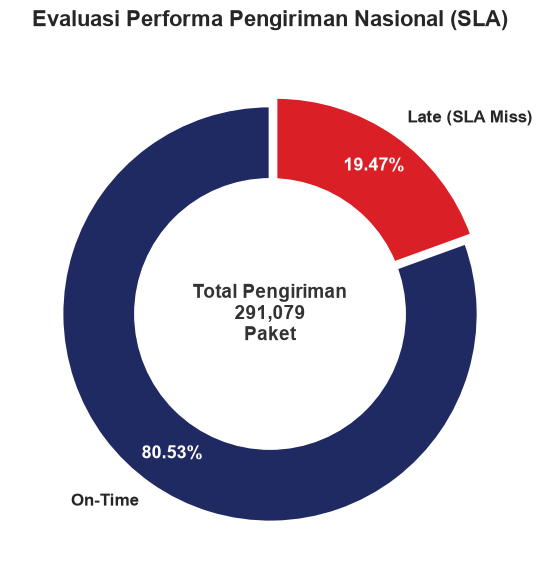

In [91]:
# Menyiapkan data
labels = ['On-Time', 'Late (SLA Miss)']
sizes = [total_on_time, total_late]
colors = ['#1f2a63', '#da1f26'] # Menggunakan warna Navy dan Merah JNE milikmu
explode = (0, 0.05) # Efek terpisah sedikit saja agar lebih elegan

# Membuat kanvas grafik
fig, ax = plt.subplots(figsize=(8, 6))

# Membuat Pie Chart dasar dan menangkap elemen teksnya
wedges, texts, autotexts = ax.pie(
    sizes, 
    explode=explode, 
    labels=labels, 
    colors=colors, 
    autopct='%1.2f%%', 
    pctdistance=0.82,  # Jarak teks persentase (harus > 0.65 agar tidak tertutup lubang donat)
    startangle=90,     
    textprops={'fontsize': 12, 'fontweight': 'bold'}, # Format untuk label luar
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# --- Trik Kustomisasi Warna Teks Persentase ---
# Mengubah khusus TEKS PERSENTASE di dalam grafik menjadi putih
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13) # Dibesarkan sedikit agar makin terbaca

# Menggambar lingkaran putih di tengah (Donut Hole)
centre_circle = plt.Circle((0,0), 0.65, fc='white')
fig.gca().add_artist(centre_circle)

# Menambahkan teks Total Transaksi di tengah "lubang" donat
plt.text(0, 0, f"Total Pengiriman\n{total_transaksi:,}\nPaket", 
         ha='center', va='center', fontsize=14, fontweight='bold', color='#333333')

# Merapikan judul dan layout
plt.title('Evaluasi Performa Pengiriman Nasional (SLA)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

# Menampilkan mahakarya
plt.show()

Sangat krusial karena hasil yang terlambat itu hampir sebesar 20% (hampir seperempat dari total transaksi), mari kita lihat lagi per jenis layanannya

--- 

In [92]:
rekap_final = df_master.groupby('service_type_clean')['sla_status'].value_counts()
rekap_final

service_type_clean  sla_status
OKE                 On-Time        72977
REG                 On-Time       143013
                    Late            2266
YES                 Late           54407
                    On-Time        18416
Name: count, dtype: int64

In [93]:
rekap_final = df_master.groupby('service_type_clean')['sla_status'].value_counts().unstack(fill_value=0)

rekap_final['Total Transaksi'] = rekap_final['Late'] + rekap_final['On-Time']
rekap_final['Late_Percentage (%)'] = (rekap_final['Late'] / rekap_final['Total Transaksi']) * 100

display(rekap_final[['Total Transaksi', 'On-Time', 'Late', 'Late_Percentage (%)']].round(2))

sla_status,Total Transaksi,On-Time,Late,Late_Percentage (%)
service_type_clean,,,,
OKE,72977,72977,0,0.00
REG,145279,143013,2266,1.56
YES,72823,18416,54407,74.71


In [94]:
df_master[(df_master['service_type_clean'] == 'YES') & (df_master['sla_status'] == 'Late') & (df_master['status'] == 'Delivered') & (df_master['delivery_duration'] == 2)]

,awb_number,sender_id,origin_branch,dest_city,payment_type,weight_kg,pickup_date,delivered_date,status,service_type_clean,...,region,city,customer_type,island_origin,island_dest,is_same_island,pickup_date_adjusted,delivery_duration,target_sla,sla_status
4,JNE000000005,CUST-20847,B-147,Surabaya,Prepaid,1.1,2023-08-22 09:00:00,2023-08-24 20:00:00,Delivered,YES,...,Bali-Nusra,Palembang,Individual,Bali_Nusa,Jawa,False,2023-08-22 09:00:00,2,1,Late
57,JNE000000059,CUST-23035,B-103,Makassar,Prepaid,8.0,2023-09-27 19:00:00,2023-09-30 22:00:00,Delivered,YES,...,Bali-Nusra,Bandung,Individual,Bali_Nusa,Sulawesi,False,2023-09-28 19:00:00,2,1,Late
66,JNE000000068,CUST-26168,B-014,Bandung,Prepaid,17.0,2023-05-18 08:00:00,2023-05-20 10:00:00,Delivered,YES,...,Jawa Barat,Bandung,Individual,Jawa,Jawa,True,2023-05-18 08:00:00,2,1,Late
88,JNE000000090,CUST-03077,B-077,Jakarta,Prepaid,13.2,2023-07-21 10:00:00,2023-07-23 12:00:00,Delivered,YES,...,Sumatera,Denpasar,Unknown,Sumatera,Jawa,False,2023-07-21 10:00:00,2,1,Late
91,JNE000000093,CUST-20423,B-146,Jakarta,Prepaid,1.1,2023-10-18 12:00:00,2023-10-21 13:00:00,Delivered,YES,...,Jabodetabek,Denpasar,Individual,Jawa,Jawa,True,2023-10-19 12:00:00,2,1,Late
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291007,JNE000299925,CUST-02228,B-075,Jakarta,Prepaid,7.5,2023-05-26 11:00:00,2023-05-29 20:00:00,Delivered,YES,...,Jawa Timur,Bandung,Corporate,Jawa,Jawa,True,2023-05-27 11:00:00,2,1,Late
291059,JNE000299980,CUST-11155,B-027,Denpasar,COD,16.6,2023-08-19 13:00:00,2023-08-22 00:00:00,Delivered,YES,...,Jawa Barat,Denpasar,Unknown,Jawa,Bali_Nusa,False,2023-08-20 13:00:00,2,1,Late
291061,JNE000299982,CUST-05265,B-107,Makassar,COD,5.5,2023-09-11 17:00:00,2023-09-14 19:00:00,Delivered,YES,...,Jabodetabek,Semarang,Unknown,Jawa,Sulawesi,False,2023-09-12 17:00:00,2,1,Late
291064,JNE000299985,CUST-16922,B-108,Bandung,COD,1.4,2023-09-23 14:00:00,2023-09-26 22:00:00,Delivered,YES,...,Bali-Nusra,Bandung,Corporate,Bali_Nusa,Jawa,False,2023-09-24 14:00:00,2,1,Late


Ternyata layanan YES yang menyumbang 74.70% keterlambatan pengiriman, ini sangatlah krusial karena layanan YES adalah layanan premium (dijanjikan besok sampai) malah menjadi kelemahan JNE sendiri, dengan kondisi seperti ini kita membuat kepuasan pelanggan menurun. 

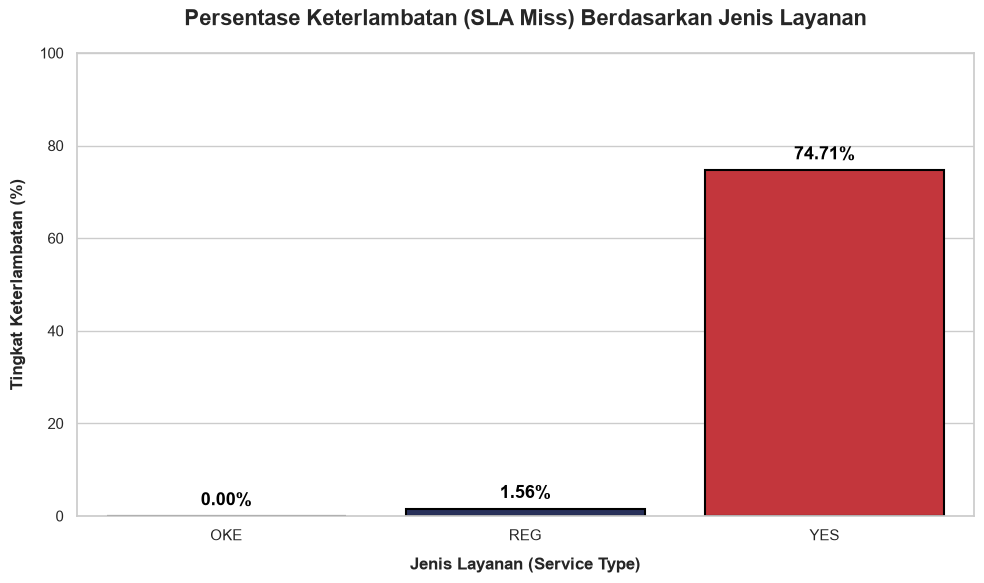

In [95]:
# Mengatur ukuran kanvas dan gaya seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Membuat Bar Chart khusus untuk persentase keterlambatan
# Kita gunakan warna gradasi bahaya (Hijau, Kuning, Merah)
ax = sns.barplot(
    x=rekap_final.index, 
    y=rekap_final['Late_Percentage (%)'],
    palette=['#2ecc71', '#1f2a63', '#da1f26'], # Warna merah diletakkan untuk YES
    linewidth=1.5,
    edgecolor='black'
)

# Menambahkan label angka persentase di atas setiap batang grafik
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

# Merapikan label dan judul
plt.title('Persentase Keterlambatan (SLA Miss) Berdasarkan Jenis Layanan', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Jenis Layanan (Service Type)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Tingkat Keterlambatan (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, 100) # Membatasi sumbu Y hingga 100%

# Menampilkan mahakarya
plt.tight_layout()
plt.show()

Temuan dari visualisasi di atas memunculkan sebuah anomali operasional yang sangat kritis ( *Critical Operational Bottleneck* ). 

Layanan **OKE** dan **REG** menunjukkan performa yang sangat prima, dengan tingkat keterlambatan masing-masing hanya **0%** dan **1.56%**. Namun, layanan **YES (Yakin Esok Sampai)** yang notabene merupakan layanan berkecepatan tinggi justru menjadi titik kelemahan utama dengan tingkat *SLA Miss* mencapai **74.71%**.

Hal ini sangat berbahaya bagi reputasi perusahaan karena layanan YES menjanjikan estimasi *Next Day* (1 hari) dengan tarif premium. Tingginya angka keterlambatan ini mengindikasikan bahwa infrastruktur *hub* sortir atau sistem distribusi di lapangan saat ini gagal mengakomodasi alur khusus ( *priority lane* ) yang dibutuhkan untuk memproses paket YES tepat waktu. 

Temuan ini mewajibkan manajemen untuk segera melakukan audit operasional terhadap rute dan kapasitas pemrosesan khusus paket YES guna mencegah terjadinya perpindahan pelanggan ke kompetitor (*customer churn*).

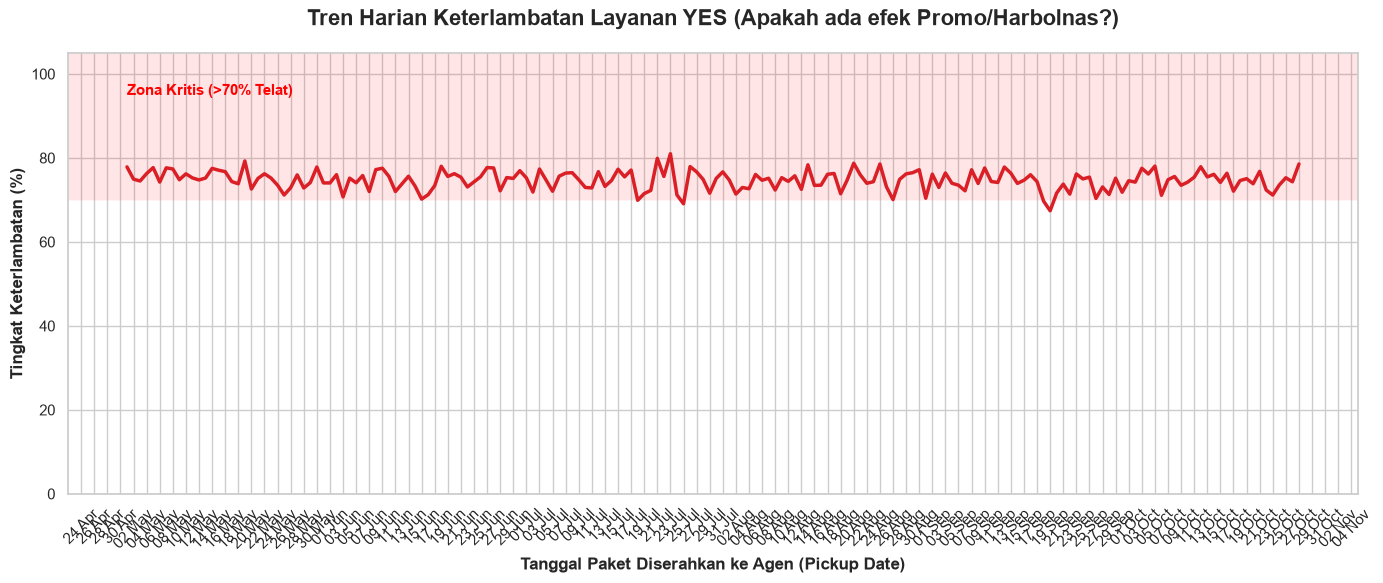

In [116]:
# 1. Ekstrak tanggal (tanpa jam) untuk melihat tren harian
df_master['pickup_date_only'] = df_master['pickup_date'].dt.date

# 2. Filter HANYA untuk layanan YES yang bermasalah
df_yes = df_master[df_master['service_type_clean'] == 'YES']

# 3. Hitung persentase keterlambatan harian
daily_yes_sla = df_yes.groupby('pickup_date_only')['sla_status'].value_counts().unstack(fill_value=0)
daily_yes_sla['Total'] = daily_yes_sla['Late'] + daily_yes_sla['On-Time']
daily_yes_sla['Late_Percentage'] = (daily_yes_sla['Late'] / daily_yes_sla['Total']) * 100

# 4. Membuat Visualisasi Line Chart (Time-Series)
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Plot garis tren persentase keterlambatan (GARIS MURNI TANPA TITIK)
ax1 = sns.lineplot(
    data=daily_yes_sla, 
    x=daily_yes_sla.index, 
    y='Late_Percentage',
    color='#da1f26', # Merah bahaya
    linewidth=2.5
)

ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Tampilkan tanggal setiap 2 hari
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)

# Menambahkan elemen informatif
plt.title('Tren Harian Keterlambatan Layanan YES (Apakah ada efek Promo/Harbolnas?)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tanggal Paket Diserahkan ke Agen (Pickup Date)', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat Keterlambatan (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 105) # Batas maksimal 100%

# Menambahkan area bayangan jika persentase di atas 70% (Kondisi Kritis)
plt.axhspan(70, 105, facecolor='red', alpha=0.1)
plt.text(daily_yes_sla.index[0], 95, 'Zona Kritis (>70% Telat)', color='red', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Dari analisis time series ini keterlambatan tidak dipengaruhi oleh tanggal / hari= / bulan, setiap harinya konstan di sekitar 70%

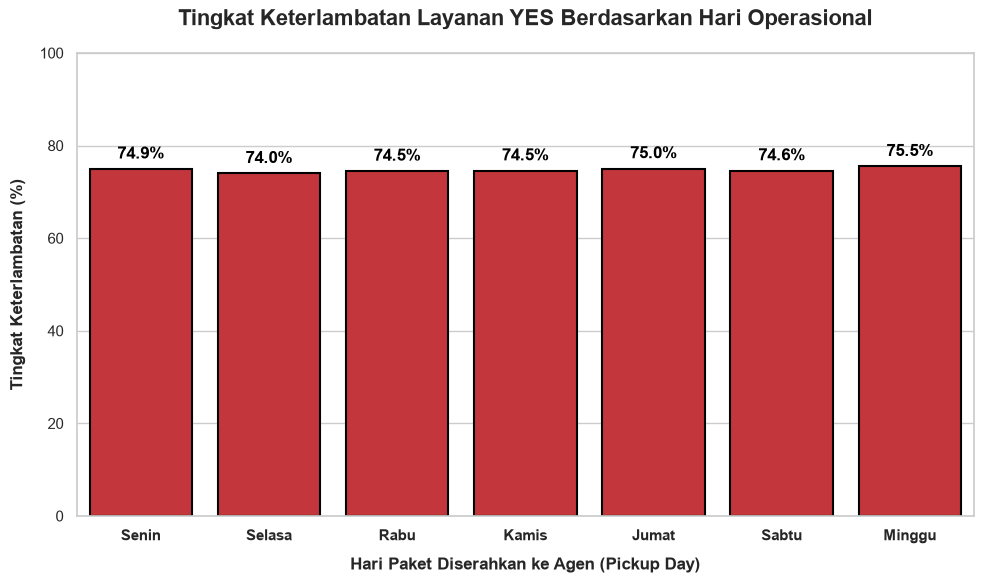

In [97]:
# 1. Mengekstrak Hari dari pickup_date
df_yes = df_master[df_master['service_type_clean'] == 'YES'].copy()
df_yes['pickup_day'] = df_yes['pickup_date'].dt.day_name()

# 2. Translasi dan Pengurutan Hari (Agar berurutan dari Senin s/d Minggu)
urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
label_indo = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
df_yes['pickup_day'] = pd.Categorical(df_yes['pickup_day'], categories=urutan_hari, ordered=True)

# 3. Menghitung persentase keterlambatan per hari
day_yes_sla = df_yes.groupby('pickup_day')['sla_status'].value_counts().unstack(fill_value=0)
day_yes_sla['Total'] = day_yes_sla['Late'] + day_yes_sla['On-Time']
day_yes_sla['Late_Percentage'] = (day_yes_sla['Late'] / day_yes_sla['Total']) * 100

# 4. Membuat Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plot grafik batang
ax = sns.barplot(
    x=day_yes_sla.index, 
    y=day_yes_sla['Late_Percentage'],
    color='#da1f26', # Menggunakan merah JNE
    linewidth=1.5,
    edgecolor='black'
)

# Menambahkan angka persentase di atas batang
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

# Merapikan label dan judul
plt.title('Tingkat Keterlambatan Layanan YES Berdasarkan Hari Operasional', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hari Paket Diserahkan ke Agen (Pickup Day)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Tingkat Keterlambatan (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylim(0, 100)

# Mengganti label sumbu X menjadi bahasa Indonesia
ax.set_xticklabels(label_indo, fontweight='bold')

plt.tight_layout()
plt.show()

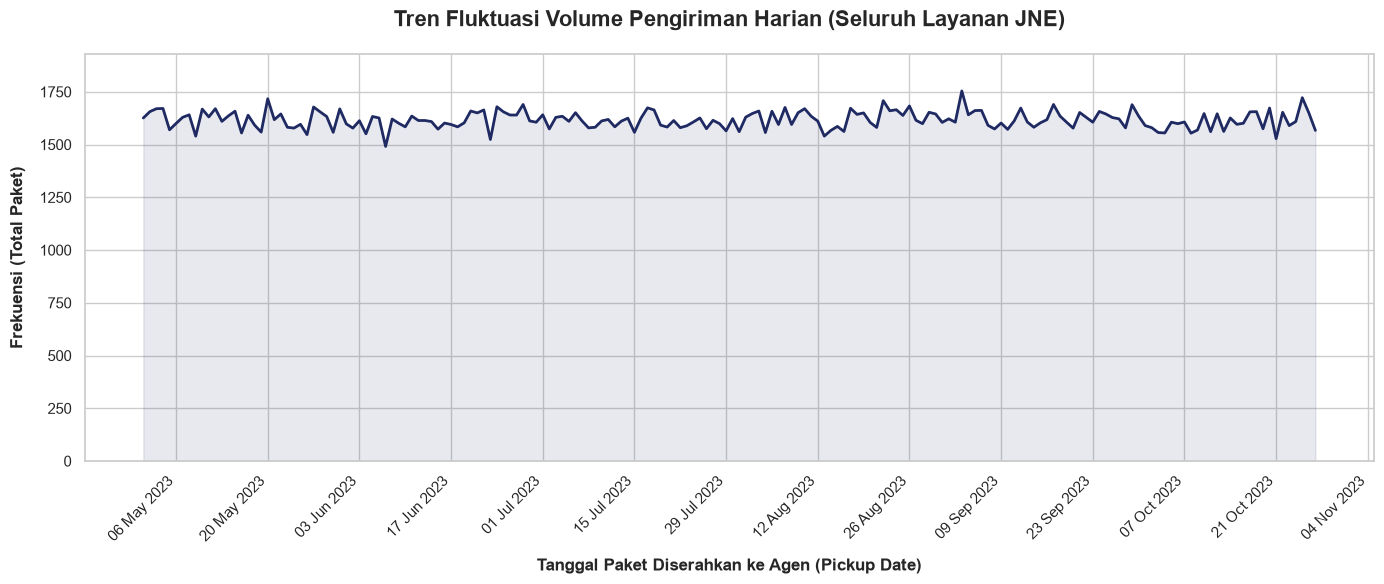

In [ ]:
# 1. Menghitung total transaksi (semua layanan) per hari
# Kita gunakan df_master yang sudah bersih
daily_volume = df_master.groupby('pickup_date_only').size().reset_index(name='total_paket')

# 2. Menyiapkan kanvas grafik
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# 3. Menggambar garis tren utama
ax = sns.lineplot(
    data=daily_volume, 
    x='pickup_date_only', 
    y='total_paket',
    color='#1f2a63', # Biru Navy khas JNE
    linewidth=2,
)

# 4. Memberikan efek bayangan (Area Chart)
plt.fill_between(daily_volume['pickup_date_only'], daily_volume['total_paket'], color='#1f2a63', alpha=0.1)

# 5. Merapikan Sumbu X (Setiap 14 Hari agar tidak bertumpuk)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=14)) 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
plt.xticks(rotation=45, ha='right')

# 6. Menambahkan anotasi/teks untuk estetika dan informasi
plt.title('Tren Fluktuasi Volume Pengiriman Harian (Seluruh Layanan JNE)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tanggal Paket Diserahkan ke Agen (Pickup Date)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Frekuensi (Total Paket)', fontsize=12, fontweight='bold', labelpad=10)

# Memberikan ruang ekstra di bagian atas sumbu Y (10% lebih tinggi dari nilai maksimal)
plt.ylim(0, daily_volume['total_paket'].max() * 1.1)

plt.tight_layout()
plt.show()

In [ ]:
rekap_bulanan = df_master['pickup_date'].dt.to_period('M').value_counts().sort_index()

print("--- Total Transaksi JNE per Bulan ---")
print(rekap_bulanan)

--- Total Transaksi JNE per Bulan ---
pickup_date
2023-05    50297
2023-06    48344
2023-07    49813
2023-08    50460
2023-09    48831
2023-10    43334
Freq: M, Name: count, dtype: int64


--- TOP 10 CABANG DENGAN PERSENTASE KETERLAMBATAN TERTINGGI ---


sla_status,branch_label,Total_Paket,On-Time,Late,Late_Percentage
0,B-047 (Jawa Tengah),1928,1486,442,22.93
1,B-035 (Jawa Timur),1900,1472,428,22.53
2,B-075 (Jawa Timur),1916,1494,422,22.03
3,B-080 (Jawa Barat),1948,1521,427,21.92
4,B-144 (Jawa Tengah),1967,1541,426,21.66
5,B-113 (Jawa Tengah),1973,1547,426,21.59
6,B-036 (Sulawesi),1927,1514,413,21.43
7,B-128 (Jawa Timur),1952,1538,414,21.21
8,B-042 (Jawa Tengah),1928,1522,406,21.06
9,B-060 (Jawa Barat),1984,1567,417,21.02


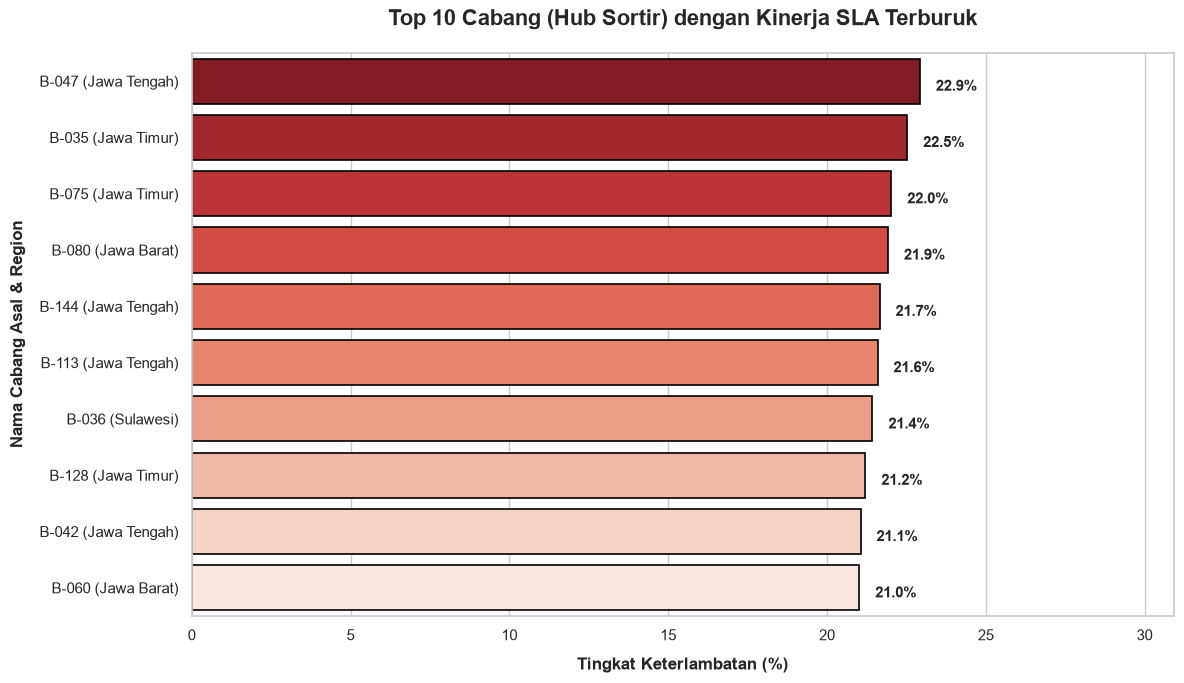

In [ ]:

# 1. Menghitung Total Transaksi dan Keterlambatan per Cabang BESERTA Region-nya
# Kita masukkan 'origin_branch' dan 'region' ke dalam groupby
branch_sla = df_master.groupby(['origin_branch', 'region'])['sla_status'].value_counts().unstack(fill_value=0)
branch_sla['Total_Paket'] = branch_sla['Late'] + branch_sla['On-Time']

# 2. Hanya ambil cabang dengan volume transaksi memadai (> 1000 paket)
branch_sla_valid = branch_sla[branch_sla['Total_Paket'] > 1000].copy()

# 3. Menghitung Persentase Keterlambatan
branch_sla_valid['Late_Percentage'] = (branch_sla_valid['Late'] / branch_sla_valid['Total_Paket']) * 100

# 4. Mengambil TOP 10 Cabang Terburuk dan mereset index agar datanya bisa dimanipulasi
top_10_worst_branches = branch_sla_valid.sort_values(by='Late_Percentage', ascending=False).head(10).reset_index()

# 5. Gabungan Kode Cabang dan Region
top_10_worst_branches['branch_label'] = top_10_worst_branches['origin_branch'] + ' (' + top_10_worst_branches['region'] + ')'

# Menampilkan Tabel Angka Mentah
print("--- TOP 10 CABANG DENGAN PERSENTASE KETERLAMBATAN TERTINGGI ---")
display(top_10_worst_branches[['branch_label', 'Total_Paket', 'On-Time', 'Late', 'Late_Percentage']].round(2))


# VISUALISASI CABANG TERBURUK (DENGAN LABEL REGION)
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Horizontal Bar Chart dengan Label Gabungan yang baru
ax = sns.barplot(
    x=top_10_worst_branches['Late_Percentage'], 
    y=top_10_worst_branches['branch_label'], # <-- Memanggil label gabungan
    palette='Reds_r', 
    edgecolor='black',
    linewidth=1.2
)

# Menambahkan label persentase di ujung setiap batang
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2. + 0.1, 
             f'{width:.1f}%', 
             ha='left', va='center', fontweight='bold', fontsize=11)

# Merapikan elemen grafik
plt.title('Top 10 Cabang (Hub Sortir) dengan Kinerja SLA Terburuk', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tingkat Keterlambatan (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Nama Cabang Asal & Region', fontsize=12, fontweight='bold', labelpad=10)

# Memberikan ruang ekstra di sumbu X agar label persentase tidak terpotong
plt.xlim(0, top_10_worst_branches['Late_Percentage'].max() + 8) 

plt.tight_layout()
plt.show()

--- PERINGKAT REGION DENGAN KINERJA SLA TERBURUK ---


sla_status,region,Total_Paket,On-Time,Late,Late_Percentage
0,Jawa Tengah,25395,20153,5242,20.64
1,Jawa Timur,17449,13868,3581,20.52
2,Jawa Barat,54171,43390,10781,19.90
3,Jabodetabek,21521,17282,4239,19.70
4,Sulawesi,46786,37827,8959,19.15
5,Bali-Nusra,48608,39331,9277,19.09
6,Sumatera,44291,35880,8411,18.99
7,Kalimantan,32858,26675,6183,18.82


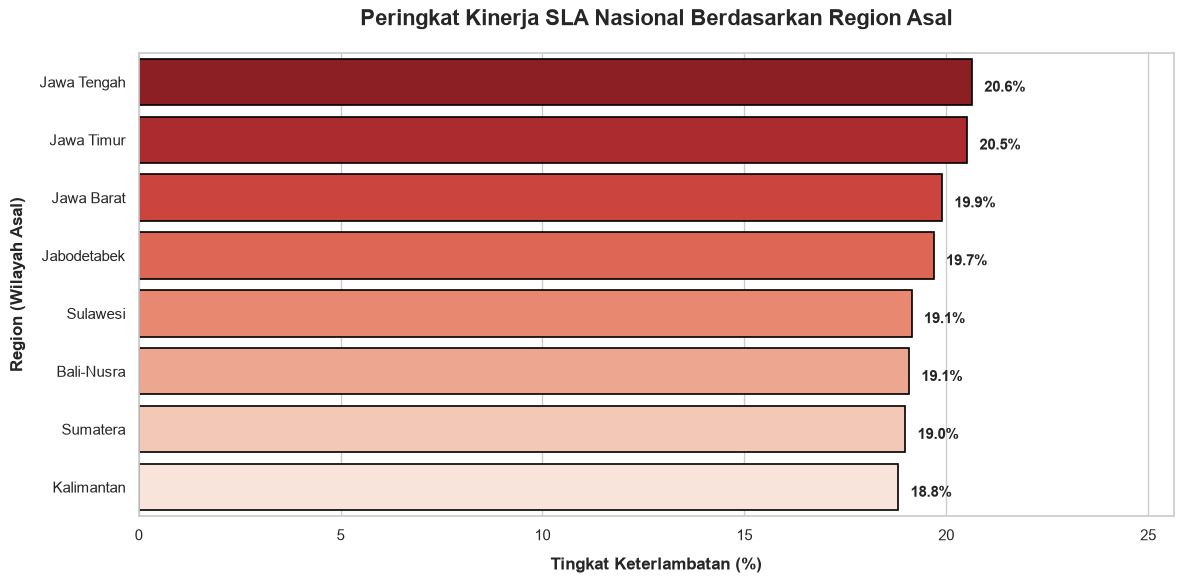

In [ ]:
# Menghitung total transaksi dan keterlambatan per-region
region_sla = df_master.groupby('region')['sla_status'].value_counts().unstack(fill_value=0)
region_sla['Total_Paket'] = region_sla['Late'] + region_sla['On-Time']
region_sla['Late_Percentage'] = (region_sla['Late'] / region_sla['Total_Paket']) * 100

# Mengurutkan dari yang terburuk
worst_regions = region_sla.sort_values(by='Late_Percentage', ascending=False).reset_index()

# Menampilkan Tabel Angka Mentah
print("--- PERINGKAT REGION DENGAN KINERJA SLA TERBURUK ---")
display(worst_regions[['region', 'Total_Paket', 'On-Time', 'Late', 'Late_Percentage']].round(2))


# VISUALISASI PERINGKAT REGION
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Horizontal Bar Chart
ax = sns.barplot(
    x=worst_regions['Late_Percentage'], 
    y=worst_regions['region'], 
    palette='Reds_r', # Semakin merah semakin darurat
    edgecolor='black',
    linewidth=1.2
)

# Menambahkan label persentase di ujung setiap batang
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.3, p.get_y() + p.get_height()/2. + 0.1, 
             f'{width:.1f}%', 
             ha='left', va='center', fontweight='bold', fontsize=11)

# Merapikan elemen grafik
plt.title('Peringkat Kinerja SLA Nasional Berdasarkan Region Asal', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tingkat Keterlambatan (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Region (Wilayah Asal)', fontsize=12, fontweight='bold', labelpad=10)

# Memberikan ruang ekstra di sumbu X agar label persentase tidak terpotong
plt.xlim(0, worst_regions['Late_Percentage'].max() + 5) 

plt.tight_layout()
plt.show()

Berdasarkan serangkaian analisis mendalam terhadap performa waktu pengiriman (SLA), kita menemukan sebuah anomali operasional yang berstatus **Kritis (Critical)** bagi kelangsungan bisnis premium JNE.

Berikut adalah sintesis temuan utama dari tahap *Exploratory Data Analysis* (EDA) pilar efisiensi waktu:

**1. Runtuhnya Performa Layanan Premium (YES)**
Secara mengejutkan, layanan standar seperti OKE dan REG tampil sangat prima dengan tingkat keterlambatan mendekati 0% - 1.5%. Sebaliknya, layanan premium **YES (Yakin Esok Sampai)** yang dijanjikan tiba dalam waktu 1 Hari, justru hancur lebur dengan tingkat *SLA Miss* mencapai **~74%**. 

**2. Kecacatan Sistemik, Bukan Karena Overload Musiman**
Analisis *Time-Series* dan volume harian membuktikan bahwa keterlambatan layanan YES terjadi secara konstan di atas 70% setiap harinya. Mengingat beban kerja operasional dalam dataset ini terdistribusi dengan sangat stabil (~1.500 paket/hari) tanpa adanya lonjakan musiman (seperti *Harbolnas* atau *Payday*), kegagalan SLA ini **bukan** disebabkan oleh *overload* kapasitas. Masalah ini murni berakar pada **Kecacatan Infrastruktur/Sistemik**.

**3. SLA Miss Terjadi Merata di Semua Provinsi**
Dalam dataset ini mencatatkan transaksi yang terjadi di 8 Provinsi dan sayangnya SLA Miss ini benar benar terjadi di seluruh provinsi, dengan Jawa Tengah sebagai provinsi yang paling sering mengalami keterlambatan. 

In [ ]:
# 1. Menyiapkan Data: Kita filter HANYA untuk layanan YES 
kolom_provinsi = 'region' 
df_yes = df_master[df_master['service_type_clean'] == 'YES'].copy()

# 2. Membuat Contingency Table (Tabel Tabulasi Silang semacam pivot table) 
contingency_table = pd.crosstab(df_yes[kolom_provinsi], df_yes['sla_status'])

# 3. Menghitung Persentase Keterlambatan per Provinsi untuk pembanding visual
contingency_table['Total'] = contingency_table.sum(axis=1)
contingency_table['Late_Percentage (%)'] = (contingency_table['Late'] / contingency_table['Total'] * 100).round(2)

# Mengurutkan dari persentase keterlambatan tertinggi
contingency_table_sorted = contingency_table.sort_values(by='Late_Percentage (%)', ascending=False)

# 4. Uji Chi-Square (Hanya menggunakan kolom Late dan On-Time)
chi2_stat, pval, dof, expected = st.chi2_contingency(contingency_table[['Late', 'On-Time']])

# 5. Hasil
print("="*75)
print(" RASIO KETERLAMBATAN YES PER PROVINSI ")
print("="*75)
display(contingency_table_sorted[['Late', 'On-Time', 'Total', 'Late_Percentage (%)']])
print("\n" + "="*75)
print(" HASIL UJI STATISTIK: CHI-SQUARE TEST OF INDEPENDENCE ")
print("="*75)
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-Value              : {pval:.4e}")
print("-" * 75)

alpha = 0.05
if pval < alpha:
    print("KESIMPULAN (Tolak H0):")
    print("Secara statistik, tingkat keterlambatan layanan YES BERGANTUNG pada provinsi.")
    print("Ada disparitas kinerja yang signifikan. Provinsi di urutan teratas tabel")
    print("terbukti memiliki performa operasional yang jauh lebih buruk dari wilayah lain.")
else:
    print("KESIMPULAN (Gagal Tolak H0):")
    print("Keterlambatan layanan YES TIDAK BERGANTUNG pada provinsi.")
    print("Masalah ini murni kecacatan sistemik yang merata di seluruh jaringan operasional.")
print("="*75)

 RASIO KETERLAMBATAN YES PER PROVINSI 


sla_status,Late,On-Time,Total,Late_Percentage (%)
region,,,,
Jawa Tengah,4881,1578,6459,75.57
Sumatera,8159,2699,10858,75.14
Jawa Timur,3338,1118,4456,74.91
Bali-Nusra,9167,3087,12254,74.81
Sulawesi,8831,3003,11834,74.62
Jawa Barat,9991,3423,13414,74.48
Kalimantan,6096,2094,8190,74.43
Jabodetabek,3944,1414,5358,73.61



 HASIL UJI STATISTIK: CHI-SQUARE TEST OF INDEPENDENCE 
Chi-Square Statistic : 7.9402
Degrees of Freedom   : 7
P-Value              : 3.3790e-01
---------------------------------------------------------------------------
KESIMPULAN (Gagal Tolak H0):
Keterlambatan layanan YES TIDAK BERGANTUNG pada provinsi.
Masalah ini murni kecacatan sistemik yang merata di seluruh jaringan operasional.


 HASIL UJI STATISTIK: PEARSON CORRELATION (SISTEMIK VS OVERLOAD) 
Koefisien Korelasi (r) : -0.0240
P-Value                : 0.7492
---------------------------------------------------------------------------
KESIMPULAN (Gagal Tolak H0):
TIDAK ADA KORELASI antara volume paket dengan tingkat keterlambatan.
Terbukti secara mutlak bahwa ini adalah KECACATAN SISTEMIK! Mau sedang sepi
atau ramai, sistem logistik YES tetap gagal memenuhi janji 1 harinya secara konstan.


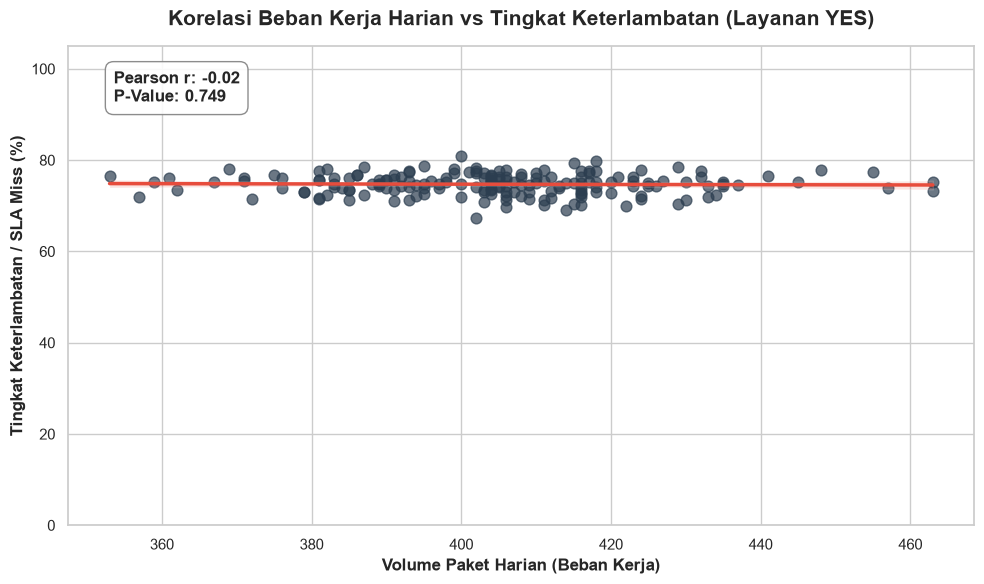

In [ ]:
# 1. Menyiapkan Data: Isolasi Layanan YES dan buat kolom tanggal harian
df_yes = df_master[df_master['service_type_clean'] == 'YES'].copy()
df_yes['pickup_date_only'] = df_yes['pickup_date'].dt.date

# 2. Agregasi Data Harian: Hitung Volume Harian & Persentase Keterlambatan Harian
daily_stats = df_yes.groupby('pickup_date_only')['sla_status'].value_counts().unstack(fill_value=0)
daily_stats['Total_Volume'] = daily_stats['Late'] + daily_stats['On-Time']
daily_stats['Late_Percentage'] = (daily_stats['Late'] / daily_stats['Total_Volume']) * 100

# 3. Uji Korelasi Pearson
# X = Total Volume Harian (Beban Kerja)
# Y = Persentase Keterlambatan (SLA Miss)
corr_coef, p_value = st.pearsonr(daily_stats['Total_Volume'], daily_stats['Late_Percentage'])

# 4. Menampilkan Hasil ala Jurnal Bisnis
print("="*75)
print(" HASIL UJI STATISTIK: PEARSON CORRELATION (SISTEMIK VS OVERLOAD) ")
print("="*75)
print(f"Koefisien Korelasi (r) : {corr_coef:.4f}")
print(f"P-Value                : {p_value:.4f}")
print("-" * 75)

alpha = 0.05
if p_value < alpha:
    print("KESIMPULAN (Tolak H0):")
    print("Ada korelasi signifikan antara volume dan keterlambatan.")
    print("Artinya, SLA Miss JNE memburuk saat beban kerja/kapasitas sedang tinggi (Overload).")
else:
    print("KESIMPULAN (Gagal Tolak H0):")
    print("TIDAK ADA KORELASI antara volume paket dengan tingkat keterlambatan.")
    print("Tidak cukup bukti adanya korelasi antara volume dan keterlambatan. Masalah keterlambatan bersifat sistemik dan tidak terkait dengan beban kerja.")
    print("Artinya mau sepi atau ramai, sistem logistik YES tetap gagal memenuhi janji 1 harinya secara konstan.")
print("="*75)



# SCATTER PLOT DENGAN REGRESSION LINE
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")


ax = sns.regplot(
    x='Total_Volume', 
    y='Late_Percentage', 
    data=daily_stats,
    scatter_kws={'color': '#2c3e50', 'alpha': 0.7, 's': 60}, # Titik sebaran harian
    line_kws={'color': '#e74c3c', 'linewidth': 2.5} # Garis tren merah
)

plt.title('Korelasi Beban Kerja Harian vs Tingkat Keterlambatan (Layanan YES)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Volume Paket Harian (Beban Kerja)', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat Keterlambatan / SLA Miss (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 105)

# Menambahkan kotak teks berisi nilai P-Value di dalam grafik
plt.text(
    0.05, 0.95, 
    f'Pearson r: {corr_coef:.2f}\nP-Value: {p_value:.3f}', 
    transform=ax.transAxes, 
    fontsize=12, fontweight='bold', 
    verticalalignment='top', 
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
)

plt.tight_layout()
plt.show()

---

## 5.3 Masalah RTS COD vs Prepaid

### RTS Berdasarkan Metode Pembayaran

Bagi JNE, paket RTS adalah kerugian ganda ( double loss ): Kurir sudah capek jalan, bensin sudah keluar, tapi JNE tidak mendapat ongkos kirim karena pembeli menolak membayar.

--- Tingkat Retur (RTS) per-Metode Pembayaran ---


status,Total_Transaksi,RTS,RTS_Percentage
payment_type,,,
COD,102129,26063,25.52
Prepaid,188950,9621,5.09


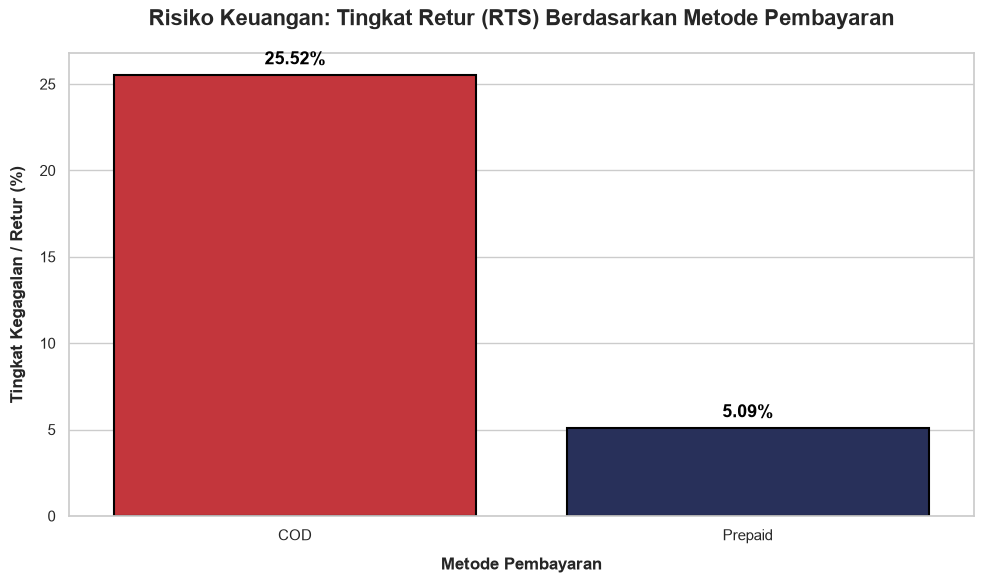

In [ ]:
rekap_retur = df_master.groupby('payment_type')['status'].value_counts().unstack(fill_value=0)
rekap_retur['Total_Transaksi'] = rekap_retur.sum(axis=1)
rekap_retur['RTS_Percentage'] = (rekap_retur['RTS'] / rekap_retur['Total_Transaksi']) * 100

print("--- Tingkat Retur (RTS) per-Metode Pembayaran ---")
display(rekap_retur[['Total_Transaksi', 'RTS', 'RTS_Percentage']].round(2))

 
# VISUALISASI PERBANDINGAN RISIKO
 
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Membuat Bar Chart perbandingan persentase
ax = sns.barplot(
    x=rekap_retur.index, 
    y=rekap_retur['RTS_Percentage'],
    palette=[ '#da1f26', '#1f2a63' ], # Biru untuk Non-COD, Merah untuk COD
    edgecolor='black',
    linewidth=1.5
)


# Menambahkan angka persentase di atas grafik
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=13, fontweight='bold', color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Risiko Keuangan: Tingkat Retur (RTS) Berdasarkan Metode Pembayaran', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Metode Pembayaran', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Tingkat Kegagalan / Retur (%)', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.show()

Berdasarkan analisis komparasi tingkat kegagalan pengiriman secara nasional, ditemukan disparitas yang sangat ekstrem antara metode pembayaran tunai (COD) dan non-tunai (Prepaid).

* Tingkat retur atau *Return to Sender* (RTS) pada layanan Non-COD (Prepaid) tergolong sangat sehat, yaitu hanya berada di angka **5.09%**.
* Sebaliknya, paket dengan metode pembayaran di tempat (COD) mencatatkan tingkat kegagalan meroket hingga **25.52%** (5 kali lipat lebih berisiko).

**Insight Bisnis:**
Data ini memvalidasi kelemahan fundamental dari sistem JNE khusus layanan COD. Metode ini memiliki risiko tinggi karena kurir diwajibkan menagih pembayaran tunai di tempat langsung kepada pembeli. Tingginya tingkat penolakan atau pembatalan paket oleh pembeli memicu tingginya status *Return to Sender* (RTS). Secara finansial, hal ini berujung pada pembengkakan biaya operasional perusahaan; armada kurir JNE terpaksa membuang waktu dan bahan bakar untuk mengembalikan barang ke lokasi penjual tanpa menerima ongkos kirim sepeser pun.

---

### Risiko COD: Kota Tujuan dengan Tingkat Retur Tertinggi

Karena kita sudah tahu bahwa COD adalah "penyakitnya" secara nasional, langkah analitis selanjutnya adalah melakukan *Deep Dive* untuk mencari tahu: Kota tujuan (`dest_city`) mana saja yang warganya paling sering melakukan RTS?

Dengan mengetahui daftar kota terburuk ini, manajemen JNE bisa mengambil tindakan strategis, seperti mencabut opsi COD untuk rute/kota tersebut (blacklist parsial) atau mewajibkan asuransi retur bagi seller yang mengirim ke sana.

--- TOP 10 KOTA DENGAN RISIKO GAGAL BAYAR COD TERTINGGI ---


status,dest_city,Total_COD,RTS,RTS_Percentage
0,Jakarta,10187,2677,26.28
1,Denpasar,10125,2656,26.23
2,Palembang,10222,2625,25.68
3,Medan,10240,2627,25.65
4,Balikpapan,10219,2597,25.41
5,Surabaya,10380,2634,25.38
6,Makassar,10236,2590,25.30
7,Semarang,10139,2563,25.28
8,Bandung,10240,2586,25.25
9,Yogyakarta,10141,2508,24.73


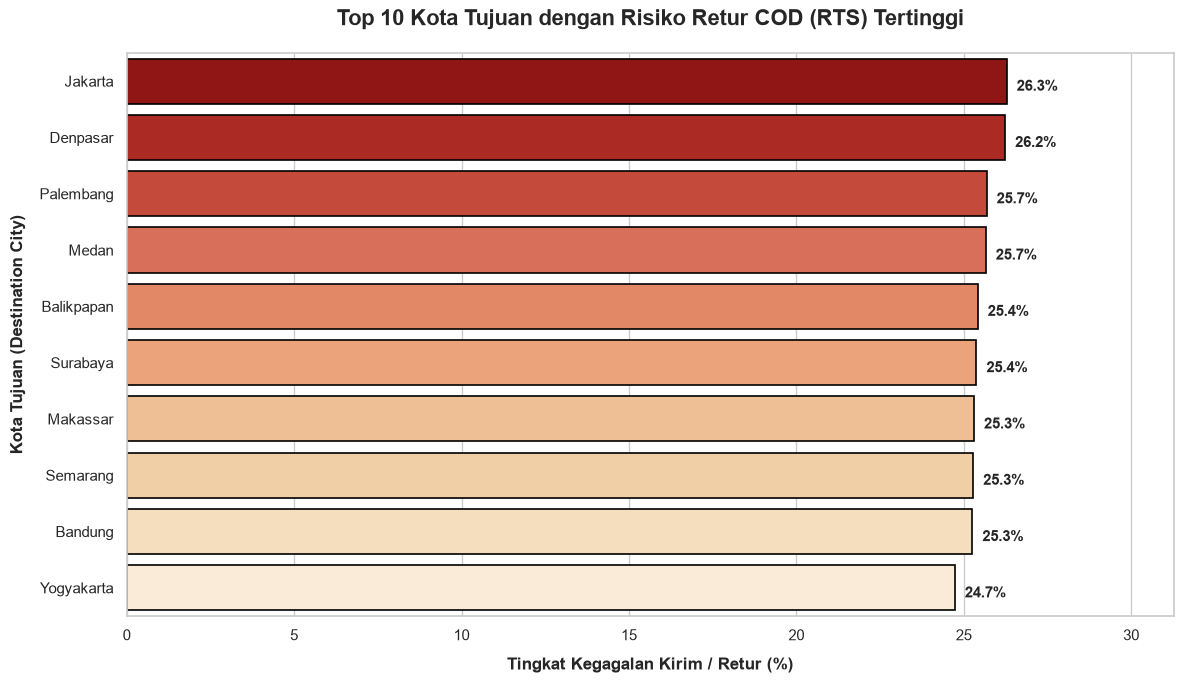

In [ ]:
# 1. FILTERING: Kita isolasi datanya HANYA untuk transaksi COD
df_cod = df_master[df_master['payment_type'] == 'COD'].copy()

# 2. MENGHITUNG RTS per KOTA TUJUAN
city_cod = df_cod.groupby('dest_city')['status'].value_counts().unstack(fill_value=0)
city_cod['Total_COD'] = city_cod.sum(axis=1)

# 3. FILTERING KOTA: Hanya ambil kota dengan volume COD yang memadai (misal > 500 paket)
# Agar kota kecil yang cuma pesan 2 paket COD dan dua-duanya gagal (100%) tidak merusak analisis
city_cod_valid = city_cod[city_cod['Total_COD'] > 500].copy()

# 4. MENGHITUNG PERSENTASE KEGAGALAN (RTS)
city_cod_valid['RTS_Percentage'] = (city_cod_valid['RTS'] / city_cod_valid['Total_COD']) * 100

# 5. MENGAMBIL TOP 10 KOTA TERBURUK
top_10_cod_cities = city_cod_valid.sort_values(by='RTS_Percentage', ascending=False).head(10).reset_index()

# Menampilkan Tabel Sanity Check
print("--- TOP 10 KOTA DENGAN RISIKO GAGAL BAYAR COD TERTINGGI ---")
display(top_10_cod_cities[['dest_city', 'Total_COD', 'RTS', 'RTS_Percentage']].round(2))

 
# VISUALISASI KOTA TERBURUK COD
 
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Horizontal Bar Chart
ax = sns.barplot(
    x=top_10_cod_cities['RTS_Percentage'], 
    y=top_10_cod_cities['dest_city'],
    palette='OrRd_r', # Gradasi Oranye-Merah (Warna peringatan bahaya)
    edgecolor='black',
    linewidth=1.2
)

# Menambahkan label persentase di ujung batang
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.3, p.get_y() + p.get_height()/2. + 0.1, 
             f'{width:.1f}%', 
             ha='left', va='center', fontweight='bold', fontsize=11)

# Merapikan elemen grafik
plt.title('Top 10 Kota Tujuan dengan Risiko Retur COD (RTS) Tertinggi', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tingkat Kegagalan Kirim / Retur (%)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Kota Tujuan (Destination City)', fontsize=12, fontweight='bold', labelpad=10)
plt.xlim(0, top_10_cod_cities['RTS_Percentage'].max() + 5) 

plt.tight_layout()
plt.show()

Setelah mengidentifikasi metode COD sebagai pusat kebocoran finansial, investigasi dilanjutkan ke level geografis. Tujuannya adalah memetakan secara spesifik kota tujuan (`dest_city`) mana saja yang mencatatkan tingkat retur tertinggi sebagai landasan pengambilan keputusan strategis.

Berdasarkan visualisasi Top 10 Kota Tujuan (*Destination City*) di atas, teridentifikasi bahwa **Jakarta** menjadi wilayah dengan performa terburuk, di mana rasio penolakan paket COD-nya menyentuh angka  **26.28%**. Posisi ini disusul ketat oleh **Denpasar (26.2%)** dan **Palembang (25.7%)**. Bahkan, kota di peringkat kesepuluh (Yogyakarta) pun masih memiliki tingkat retur yang sangat tinggi di angka **24.7%**.

Berarti bukan masalah kota destinasinya tetapi memang fitur COD ini membuat kebiasaan konsumen menjadi mudah untuk meretur barang

In [ ]:
 
# STATISTIK INFERENSIAL 5: Chi-Square Test (Risiko Retur COD vs Kota Tujuan)
 

# 1. Menyiapkan Data: Isolasi HANYA transaksi COD
df_cod = df_master[df_master['payment_type'] == 'COD'].copy()

# 2. Mengambil Top 10 Kota Tujuan dengan Volume COD Terbesar agar relevan diuji
# Sesuaikan 'dest_city' dengan nama kolom aslimu jika berbeda
top_10_cities = df_cod['dest_city'].value_counts().head(10).index
df_cod_top10 = df_cod[df_cod['dest_city'].isin(top_10_cities)]

# 3. Membuat Contingency Table (Tabel Tabulasi Silang)
contingency_cod = pd.crosstab(df_cod_top10['dest_city'], df_cod_top10['status'])

# 4. Menghitung Persentase Retur (RTS) per Kota
contingency_cod['Total'] = contingency_cod.sum(axis=1)
# Asumsi nama kolom retur adalah 'RTS'. Sesuaikan jika menggunakan huruf kecil 'rts'
contingency_cod['RTS_Percentage (%)'] = (contingency_cod['RTS'] / contingency_cod['Total'] * 100).round(2)

# Mengurutkan dari yang persentase returnya paling tinggi
contingency_cod_sorted = contingency_cod.sort_values(by='RTS_Percentage (%)', ascending=False)

# 5. Mengeksekusi Uji Chi-Square (Kita filter hanya kolom status asli, buang kolom Total & Persentase)
kolom_status = [col for col in contingency_cod.columns if col not in ['Total', 'RTS_Percentage (%)']]
chi2_stat, pval, dof, expected = st.chi2_contingency(contingency_cod[kolom_status])

# 6. Menampilkan Hasil ala Jurnal Bisnis
print("="*75)
print(" RASIO RETUR COD PADA TOP 10 KOTA TUJUAN ")
print("="*75)
display(contingency_cod_sorted[kolom_status + ['Total', 'RTS_Percentage (%)']])
print("\n" + "="*75)
print(" HASIL UJI STATISTIK: CHI-SQUARE TEST (RETUR COD VS KOTA TUJUAN) ")
print("="*75)
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"P-Value              : {pval:.4e}")
print("-" * 75)

# Logika Kesimpulan Otomatis
alpha = 0.05
if pval < alpha:
    print("KESIMPULAN (Tolak H0):")
    print("Secara statistik, tingkat retur COD BERGANTUNG pada kota tujuan.")
    print("Ada kota-kota tertentu yang warganya secara signifikan memiliki tabiat")
    print("lebih buruk dalam menolak paket COD dibandingkan kota lain.")
else:
    print("KESIMPULAN (Gagal Tolak H0):")
    print("Tingkat retur COD TIDAK BERGANTUNG pada kota tujuan (Independen).")
    print("Ini BUKAN masalah geografi, melainkan KECACATAN SISTEMIK pada model bisnis COD.")
    print("Di manapun areanya, fitur COD terbukti mendorong perilaku retur yang sangat tinggi.")
print("="*75)

 RASIO RETUR COD PADA TOP 10 KOTA TUJUAN 


status,Damaged,Delivered,Lost,RTS,Total,RTS_Percentage (%)
dest_city,,,,,,
Jakarta,309,7004,197,2677,10187,26.28
Denpasar,291,6970,208,2656,10125,26.23
Palembang,345,7055,197,2625,10222,25.68
Medan,327,7049,237,2627,10240,25.65
Balikpapan,329,7067,226,2597,10219,25.41
Surabaya,320,7226,200,2634,10380,25.38
Makassar,275,7158,213,2590,10236,25.30
Semarang,301,7055,220,2563,10139,25.28
Bandung,313,7148,193,2586,10240,25.25



 HASIL UJI STATISTIK: CHI-SQUARE TEST (RETUR COD VS KOTA TUJUAN) 
Chi-Square Statistic : 32.9633
P-Value              : 1.9828e-01
---------------------------------------------------------------------------
KESIMPULAN (Gagal Tolak H0):
Tingkat retur COD TIDAK BERGANTUNG pada kota tujuan (Independen).
Ini BUKAN masalah geografi, melainkan KECACATAN SISTEMIK pada model bisnis COD.
Di manapun areanya, fitur COD terbukti mendorong perilaku retur yang sangat tinggi.


---

## 5.4 Kebocoran Omzet Akibat Weight Outliers

Sesuai dengan bedah bisnis JNE kita sebelumnya, masalah ini berakar dari kesalahan manusia (human error) atau manipulasi saat penimbangan berat paket di gerai agen. Masalah operasional ini bisa terlihat pada dataset dalam bentuk weight outliers (anomali berat), seperti berat bernilai minus/nol atau ekstrem di atas 50 kg. Tujuan akhir kita di pilar ini sangat jelas: menghitung potensi kebocoran omzet akibat selisih tarif ongkos kirim. Di sini kita kembali menggunakan `df_shipments` karena data anomali berat paket sudah di-*flagging* di dataset ini

In [107]:
df_anomaly = df_shipments[df_shipments['weight_kg'] <= 0].copy()
total_paket_anomali = len(df_anomaly)

display(df_anomaly['weight_kg'].value_counts().sort_index())
# Total Berat Anomali
df_anomaly['true_weight'] = df_anomaly['weight_kg'].abs()
total_berat_anomali = df_anomaly['true_weight'].sum()

# Asumsi dipukul rata 1 kg
berat_minimum_kg = 1 
minimal_hilang = total_paket_anomali * berat_minimum_kg

# Simulasi Finansial
asumsi_tarif_per_kg = 25000  # Asumsi rata-rata ongkir Rp 10.000 / kg
potensi_kerugian_minimal = minimal_hilang * asumsi_tarif_per_kg
potensi_kerugian_maksimal = total_berat_anomali * asumsi_tarif_per_kg

print(f"1. Total Paket dengan Berat Ilegal (<= 0 kg) : {total_paket_anomali:,} paket")
print(f"2. Estimasi Minimum yang Tidak Tertagih      : {minimal_hilang:,} kilogram")
print(f"3. Estimasi Maksimal                         : {total_berat_anomali:,.1f} kilogram")
print("-" * 75)
print(f"4. Asumsi Tarif Rata-rata Nasional           : Rp {asumsi_tarif_per_kg:,} / kg")
print(f"5. RENTANG POTENSI KEBOCORAN OMZET           : Rp {potensi_kerugian_minimal:,.2f} s/d Rp {potensi_kerugian_maksimal:,.2f}")

weight_kg
-5.0    368
-1.5    401
Name: count, dtype: int64

1. Total Paket dengan Berat Ilegal (<= 0 kg) : 769 paket
2. Estimasi Minimum yang Tidak Tertagih      : 769 kilogram
3. Estimasi Maksimal                         : 2,441.5 kilogram
---------------------------------------------------------------------------
4. Asumsi Tarif Rata-rata Nasional           : Rp 25,000 / kg
5. RENTANG POTENSI KEBOCORAN OMZET           : Rp 19,225,000.00 s/d Rp 61,037,500.00


Ditemukan adanya celah kebocoran finansial (*revenue leakage*) yang berakar dari anomali data operasional. Terdapat **769 paket** yang lolos dari sistem dengan catatan bobot tidak masuk akal (bernilai 0 atau minus).

Untuk menghitung dampak finansial dari anomali ini, dilakukan simulasi perhitungan berbasis dua skenario dengan menggunakan asumsi tarif rata-rata pengiriman riil nasional sebesar **Rp 25.000 / kg**:

*   **Skenario Konservatif (Kerugian Minimum):** Berdasarkan aturan logistik, barang sekecil apapun akan ditagih tarif minimum 1 kg. Jika diasumsikan seluruh paket anomali tersebut berbobot 1 kg, JNE kehilangan hak tagih atas 769 kg tonase. Hal ini setara dengan potensi omzet yang menguap sebesar **Rp 19.225.000**.
*   **Skenario Berdasarkan Asumsi Typo:** Mengingat input minus (seperti -5 kg atau -1.5 kg) memiliki probabilitas tinggi sebagai ketidaksengajaan ketik (*typo*) oleh agen di lapangan dan menghasilkan total estimasi sebesar 2.441,5 kg. Pada skenario riil ini, potensi kerugian omzet perusahaan meroket tajam hingga **Rp 61.037.500**.

**Insight Bisnis:**
Temuan ini membuktikan bahwa masalah kualitas data bukan sekadar isu administratif, melainkan berdampak langsung pada kerugian profitabilitas. Kelemahan sistem pada proses *input* manual di titik gerai agen (tidak adanya sistem validasi yang memblokir angka minus) menyebabkan perusahaan kehilangan puluhan juta rupiah. Nominal kerugian ini tergolong sangat masif dan menjadi peringatan untuk lebih memerhatikan kualitas data

---

--- TOP 10 CABANG PENYUMBANG KEBOCORAN OMZET (SUDAH DITERJEMAHKAN) ---


,origin_branch,branch_name,Total_Paket_Anomali,Potensi_Kerugian_Rp
0,B-069,JNE Cabang Utama 69,12,1237500.0
1,B-017,JNE Cabang Utama 17,10,987500.0
2,B-116,JNE Cabang Utama 116,10,900000.0
3,B-025,JNE Cabang Utama 25,9,862500.0
4,B-044,JNE Cabang Utama 44,8,825000.0
5,B-029,JNE Cabang Utama 29,8,825000.0
6,B-100,JNE Cabang Utama 100,8,825000.0
7,B-133,JNE Cabang Utama 133,10,812500.0
8,B-047,JNE Cabang Utama 47,10,812500.0
9,B-013,JNE Cabang Utama 13,10,812500.0


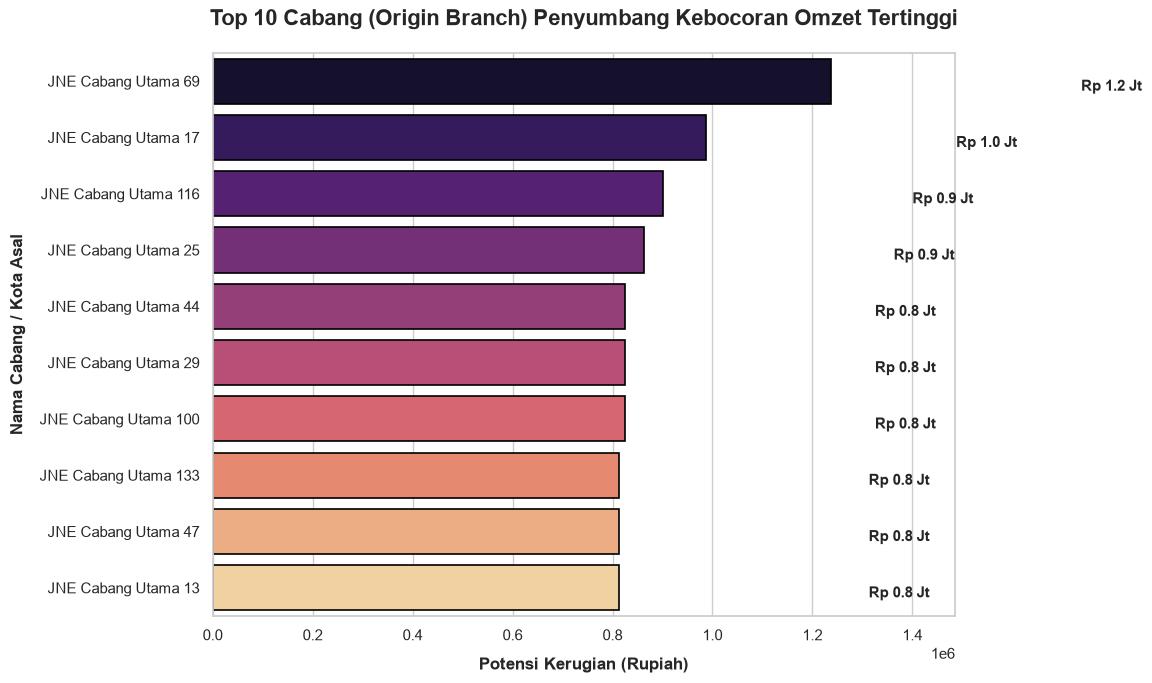

In [ ]:
# 1. Menyiapkan Data Barang Bukti
df_anomaly = df_shipments[df_shipments['weight_kg'] <= 0].copy()
df_anomaly['true_weight'] = df_anomaly['weight_kg'].abs()

# 2. Mengelompokkan Total Kerugian berdasarkan Kode Cabang Asal
branch_leakage = df_anomaly.groupby('origin_branch').agg(
    Total_Paket_Anomali=('weight_kg', 'count'),
    Total_Tonase_Hilang=('true_weight', 'sum')
).reset_index()

# 3. Menghitung Potensi Kerugian Rupiah per Cabang (Skenario Agresif Rp 25.000)
asumsi_tarif = 25000
branch_leakage['Potensi_Kerugian_Rp'] = branch_leakage['Total_Tonase_Hilang'] * asumsi_tarif

# 4. Mengambil TOP 10 Cabang Terburuk (Hanya Kode Cabang)
top_10_leakage = branch_leakage.sort_values(by='Potensi_Kerugian_Rp', ascending=False).head(10)

# ------------------------------------------------------------------------------
# 5. MERGING DENGAN DF_BRANCHES (Menerjemahkan Kode Menjadi Nama Cabang)
# ------------------------------------------------------------------------------
# Menggabungkan data agar kita mendapatkan nama cabang/kota yang sebenarnya
top_10_leakage_named = pd.merge(
    top_10_leakage, 
    df_branches, 
    left_on='origin_branch', 
    right_on='branch_code', 
    how='inner'
)

# Catatan: Asumsi nama kolom yang berisi nama wilayah di df_branches adalah 'branch_name'. 
# Jika di datasetmu namanya 'city_name' atau 'branch_city', silakan diubah di baris visualisasi bagian y=... di bawah.

# Menampilkan Tabel Mentah untuk Sanity Check
print("--- TOP 10 CABANG PENYUMBANG KEBOCORAN OMZET (SUDAH DITERJEMAHKAN) ---")
display(top_10_leakage_named[['origin_branch', 'branch_name', 'Total_Paket_Anomali', 'Potensi_Kerugian_Rp']].round(1))

 
# VISUALISASI CABANG TERBURUK (REVENUE LEAKAGE)
 
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Horizontal Bar Chart (SEKARANG MENGGUNAKAN NAMA CABANG)
ax = sns.barplot(
    x='Potensi_Kerugian_Rp', 
    y='branch_name', # <-- Gunakan nama cabang, bukan lagi origin_branch
    data=top_10_leakage_named,
    palette='magma', 
    edgecolor='black',
    linewidth=1.2
)

# Format angka di ujung batang menjadi format "Juta Rupiah" (Jt)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 500000, p.get_y() + p.get_height()/2. + 0.1, 
                 f'Rp {width/1000000:.1f} Jt', 
                 ha='left', va='center', fontweight='bold', fontsize=11)

# Merapikan elemen grafik
plt.title('Top 10 Cabang (Origin Branch) Penyumbang Kebocoran Omzet Tertinggi', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Potensi Kerugian (Rupiah)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Nama Cabang / Kota Asal', fontsize=12, fontweight='bold', labelpad=10)

# Memberikan ruang ekstra di sumbu X agar teks "Jt" tidak terpotong
plt.xlim(0, top_10_leakage_named['Potensi_Kerugian_Rp'].max() * 1.2) 

plt.tight_layout()
plt.show()

--- KEBOCORAN OMZET BERDASARKAN REGIONAL ---


,region,Total_Paket_Anomali,Total_Tonase_Hilang,Potensi_Kerugian_Rp
2,Jawa Barat,140,444.5,11112500.0
7,Sumatera,139,404.5,10112500.0
6,Sulawesi,115,372.0,9300000.0
0,Bali-Nusra,105,350.0,8750000.0
5,Kalimantan,88,279.0,6975000.0
1,Jabodetabek,66,211.0,5275000.0
3,Jawa Tengah,64,208.0,5200000.0
4,Jawa Timur,52,172.5,4312500.0


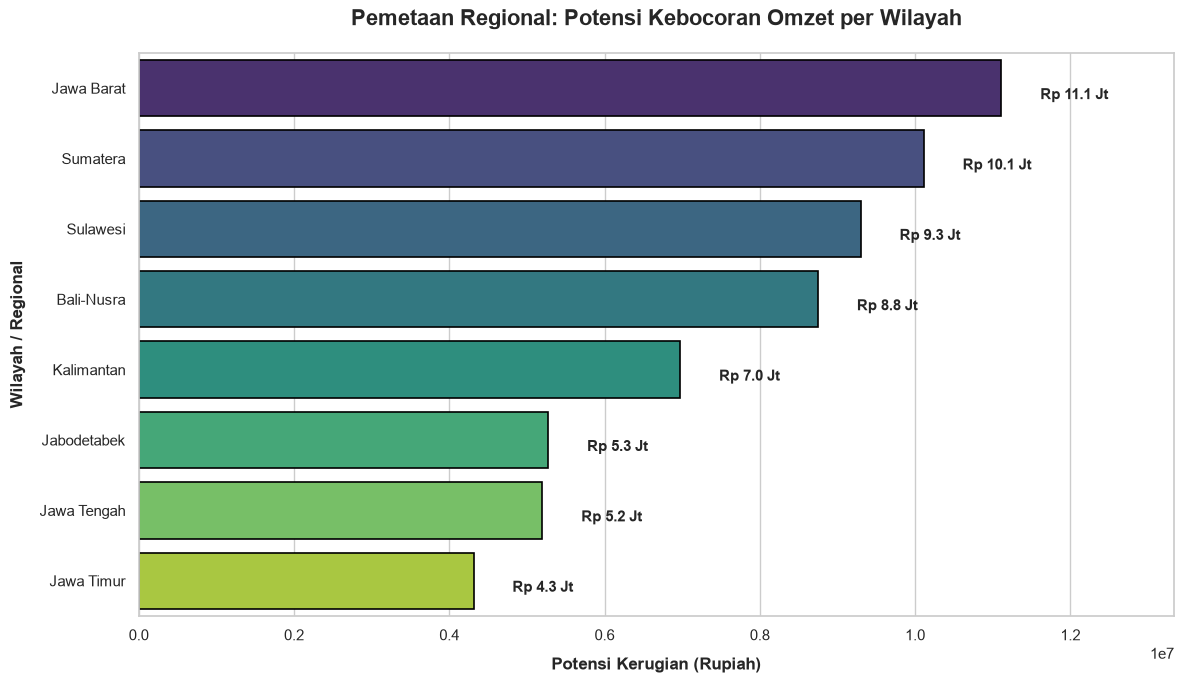

In [ ]:
# 1. Pastikan df_anomaly sudah memiliki kolom 'true_weight' (absolut)
df_anomaly = df_shipments[df_shipments['weight_kg'] <= 0].copy()
df_anomaly['true_weight'] = df_anomaly['weight_kg'].abs()

# 2. MERGING KESELURUHAN DATA ANOMALI DENGAN TABEL CABANG
df_anomaly_region = pd.merge(
    df_anomaly, 
    df_branches, 
    left_on='origin_branch', 
    right_on='branch_code', 
    how='inner'
)


# 3. Mengelompokkan Total Kerugian berdasarkan Wilayah/Region
region_leakage = df_anomaly_region.groupby('region').agg(
    Total_Paket_Anomali=('weight_kg', 'count'),
    Total_Tonase_Hilang=('true_weight', 'sum')
).reset_index()

# 4. Menghitung Potensi Kerugian Rupiah (Skenario Agresif Tarif Rp 25.000)
asumsi_tarif = 25000
region_leakage['Potensi_Kerugian_Rp'] = region_leakage['Total_Tonase_Hilang'] * asumsi_tarif

# 5. Mengurutkan dari Region penyumbang kerugian terbesar
region_leakage = region_leakage.sort_values(by='Potensi_Kerugian_Rp', ascending=False)

# Menampilkan Tabel untuk Executive Summary
print("--- KEBOCORAN OMZET BERDASARKAN REGIONAL ---")
display(region_leakage.round(1))

 
# VISUALISASI KERUGIAN REGIONAL
 
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Bar Chart
ax = sns.barplot(
    x='Potensi_Kerugian_Rp', 
    y= 'region',
    data=region_leakage,
    palette='viridis', # Gradasi warna berbeda untuk visualisasi regional
    edgecolor='black',
    linewidth=1.2
)

# Format angka menjadi "Juta Rupiah" (Jt)
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        plt.text(width + 500000, p.get_y() + p.get_height()/2. + 0.1, 
                 f'Rp {width/1000000:.1f} Jt', 
                 ha='left', va='center', fontweight='bold', fontsize=11)

# Merapikan elemen grafik
plt.title('Pemetaan Regional: Potensi Kebocoran Omzet per Wilayah', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Potensi Kerugian (Rupiah)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Wilayah / Regional', fontsize=12, fontweight='bold', labelpad=10)

# Memberikan ruang ekstra di sumbu X agar teks tidak terpotong
plt.xlim(0, region_leakage['Potensi_Kerugian_Rp'].max() * 1.2) 

plt.tight_layout()
plt.show()

Setelah mengidentifikasi kerugian di level cabang, analisis ditarik ke level strategis (regional) untuk memetakan pola persebaran anomali secara makro. Pendekatan ini bertujuan untuk mengevaluasi performa tata kelola operasional di bawah kendali masing-masing *Regional Manager*.

**Temuan Utama:**
* **Jawa Barat** menempati peringkat pertama sebagai wilayah dengan tingkat kebocoran omzet tertinggi, mencatatkan kerugian sebesar **Rp 11,1 Juta**.
* Posisi kedua disusul oleh **Sumatera** dengan angka kerugian **Rp 10,1 Juta**, dan diikuti oleh **Sulawesi** di angka **Rp 9,3 Juta**.
* Sebaliknya, wilayah episentrum bisnis seperti **Jabodetabek** justru mencatatkan angka kebocoran yang jauh lebih rendah (Rp 5,3 Juta), mengindikasikan adanya disparitas standar kedisiplinan atau pengawasan antara wilayah ibu kota dan wilayah ekspansi lainnya.

**Insight Bisnis:**
Kebocoran finansial ini terbukti bukan sekadar anomali lokal di satu cabang, melainkan masalah tata kelola operasional berskala regional. Mengingat masih banyak gerai agen JNE di daerah yang mengandalkan sistem *input* manual saat proses *pickup*, wilayah seperti Jawa Barat dan Sumatera terbukti memiliki kerentanan paling tinggi terhadap kesalahan penimbangan berat barang. Data ini merupakan landasan faktual yang sangat kuat bagi *Management* untuk mengevaluasi manajer wilayah terkait dan segera menginstruksikan audit operasional secara *Top-Down*.

---

## 5.6 Analisis Customer

## Frekuensi Transaksi Customer

In [110]:
#1. Menggabungkan data transaksi dengan data pelanggan (jika belum digabung sebelumnya)
df_sales_analysis = pd.merge(df_shipments, df_customers, left_on='sender_id', right_on='customer_id', how='inner')

# 2. Agregasi Kuantitas: Menghitung Total Transaksi untuk SELURUH Pelanggan
comprehensive_frequency = df_sales_analysis.groupby(['customer_id', 'customer_type']).agg(
        Total_Transaksi=('awb_number', 'count')
).reset_index()

# 3. Mengurutkan untuk melihat TOP 15 Pelanggan Paling Aktif secara Nasional
top_15_all_customers = comprehensive_frequency.sort_values(by='Total_Transaksi', ascending=False).head(15)


display(top_15_all_customers.reset_index(drop=True).style.format({
    'Total_Transaksi': '{:,.0f}'
}))
print("="*85)

,customer_id,customer_type,Total_Transaksi
0,CUST-27835,Corporate,25
1,CUST-06266,Individual,24
2,CUST-08627,Corporate,24
3,CUST-05006,Individual,22
4,CUST-13532,Individual,22
5,CUST-11909,Individual,22
6,CUST-09940,Individual,22
7,CUST-06957,Corporate,22
8,CUST-04038,Unknown,22
9,CUST-17170,Unknown,21


Terlihat dari top 15 `customer_type` selisihnya tidak berbeda jauh, selanjutnya mari kita lihat rata rata perpelanggan

In [111]:
print(f'rata-rata transaksi per pelanggan: {comprehensive_frequency["Total_Transaksi"].mean():,.0f}')

rata-rata transaksi per pelanggan: 10


In [112]:
# Step 1: Hitung jumlah transaksi per customer (semua tipe)
transaksi_per_customer = (
    df_sales_analysis.groupby(['customer_id', 'customer_type'])['awb_number']
    .count()
    .reset_index()
    .rename(columns={'awb_number': 'jumlah_transaksi'})
)

# Step 2: Hitung rata-rata transaksi semua customer
rata_rata = transaksi_per_customer['jumlah_transaksi'].mean()
print(f"Rata-rata transaksi semua customer: {rata_rata:.2f}")

# Step 3: Filter Corporate yang di bawah rata-rata
result = transaksi_per_customer[
    (transaksi_per_customer['customer_type'] == 'Corporate') &
    (transaksi_per_customer['jumlah_transaksi'] < rata_rata)
].sort_values('jumlah_transaksi')

print(result)

Rata-rata transaksi semua customer: 10.00
      customer_id customer_type  jumlah_transaksi
21214  CUST-21216     Corporate                 1
8061   CUST-08062     Corporate                 1
3922   CUST-03923     Corporate                 2
12905  CUST-12907     Corporate                 2
3722   CUST-03723     Corporate                 2
...           ...           ...               ...
17469  CUST-17471     Corporate                10
17296  CUST-17298     Corporate                10
17302  CUST-17304     Corporate                10
29914  CUST-29916     Corporate                10
29953  CUST-29955     Corporate                10

[4382 rows x 3 columns]


In [113]:
# Step 1: Hitung jumlah transaksi per customer
transaksi_per_customer = (
    df_sales_analysis.groupby(['customer_id', 'customer_type'])['awb_number']
    .count()
    .reset_index()
    .rename(columns={'awb_number': 'jumlah_transaksi'})
)

# Step 2: Rata-rata transaksi per customer_type
rata_rata_per_type = (
    transaksi_per_customer
    .groupby('customer_type')['jumlah_transaksi']
    .mean()
    .reset_index()
    .rename(columns={'jumlah_transaksi': 'rata_rata_transaksi'})
    .sort_values('rata_rata_transaksi', ascending=False)
)

print(rata_rata_per_type)

  customer_type  rata_rata_transaksi
2       Unknown            10.017912
1    Individual            10.010673
0     Corporate             9.965050


Sebagai bagian dari evaluasi tata kelola data pelanggan (*Customer Data Governance*), analisis dilanjutkan untuk memetakan perilaku pengiriman berdasarkan jenis pelanggan (*customer_type*). Analisis ini bertujuan untuk melihat seberapa besar potensi komersial yang dapat digarap oleh tim *B2B Sales* melalui strategi *cross-selling* dan optimalisasi akun.

**Temuan Utama & Realita Data:**
*   **Dominasi Pengirim Skala Menengah (UMKM):** Berdasarkan agregasi makro, rata-rata transaksi per pelanggan di dalam sistem tercatat di angka **10 transaksi**, dengan volume pengiriman tertinggi mencapai **25 transaksi**. 
*   **Ketiadaan Skala Korporasi Murni:** Data menunjukkan bahwa akun berstatus **Corporate** memiliki rata-rata transaksi harian sebesar **9.96**, yang mana angka ini bahkan sedikit lebih rendah dibandingkan kategori *Individual* (10.01) dan *Unknown* (10.01). 
*   **Indikasi Cacat Klasifikasi / Churn Risk:** Terdapat ribuan akun berstatus *Corporate* dengan volume pengiriman di bawah rata-rata (1–10 transaksi). Kondisi ini mengindikasikan dua hal krusial: adanya kesalahan klasifikasi saat agen menginput data pendaftaran (*fake corporate*), atau akun-akun korporat besar dulunya aktif namun kini telah mengalami penurunan volume drastis (*churn*).



---

# Conclusion

Di sini kita melihat temuan-temuan masalah dari semua langkah yang sudah di lakukan dan membagi masalahnya menjadi 2 kelompok

## Masalah 1: Audit Sistem & Tata Kelola Data (Data Governance)

Evaluasi tahap pertama berfokus pada kualitas infrastruktur frontend (sistem agen) dan midstream (sistem pemrosesan). Berdasarkan hasil analisis data transaksi, ditemukan tiga titik kelemahan kritis pada tata kelola data yang secara langsung menghambat pelaporan manajemen dan membatasi peluang komersial perusahaan:

1. Inkonsistensi Penulisan Nama Layanan (Service Type)
- Fakta Data: Ditemukan total kesalahan ketik (typo) sebanyak 134.895 baris, yang merepresentasikan 44,96% dari total keseluruhan data. 
- Rincian Anomali       : Tingkat typo ini terjadi di seluruh produk, meliputi 59,88% typo pada layanan OKE, 40,06% pada layanan YES, dan 39,94% pada layanan REG.
- Akar Masalah          : Tingginya tingkat inkonsistensi penulisan ini membuktikan bahwa agen di gerai fisik masih diberikan keleluasaan melakukan free-text input pada sistem POS (Point of Sale).
- Dampak Bisnis         : Tanpa adanya proses cleaning, agregasi volume pengiriman per layanan di dashboard manajemen akan terpecah-pecah dan menghasilkan pelaporan yang menyesatkan (misleading).

2. Logical Error pada Sistem Pemrosesan (Timestamp)
- Fakta Data            : Dari total 300.000 baris master data yang menyimpan barang bukti, terdapat 7.473 baris data yang mengalami logical error pada waktu.  
- Dampak Bisnis         : Kegagalan sistem pencatatan waktu yang mencakup 2,49% dari total keseluruhan data ini mengindikasikan adanya kecacatan pada sistem pemrosesan operasional scanner resi. Lebih fatal lagi, data waktu yang cacat ini secara langsung merusak integritas analisis performa waktu pengiriman (SLA). Jika dibiarkan, hal ini akan memicu bias pada pelaporan dan berisiko membuat manajemen mengeluarkan rekomendasi atau keputusan operasional yang keliru (misalnya salah mengevaluasi cabang operasional akibat data metrik yang tidak valid).

3. Blind Spot Data Pelanggan (Missing Values) & Peluang Cross-Selling
- Fakta Data            : Terdapat lebih dari 4.500 pelanggan dengan data kosong (null/NaN) pada kolom tipe pelanggan, yang menyebabkan tim Sales JNE kehilangan profil dari 15,26% pelanggannya.
- Tindakan Penanganan   : Data kosong ini diubah menjadi kategori 'Unknown' sebagai pendekatan best practice agar data tetap bisa dianalisis. Jika sistem sembarangan memaksa mengisi data tak dikenal tersebut dengan label 'Individual' atau 'Corporate', hal tersebut berisiko menyesatkan strategi cross-selling tim Sales di masa depan.
- Dampak bisnis         : Jika data ini lengkap, tim B2B Sales JNE sebenarnya bisa memanfaatkannya untuk mem-follow up pengirim individu berskala besar agar di-upgrade menjadi akun Corporate melalui strategi cross-selling.  

## Masalah 2: Audit Operasional & Finansial (Field Operations & Revenue)

Setelah mengevaluasi keandalan sistem pada tahap pertama, fokus analisis beralih pada pergerakan operasional di lapangan dan dampaknya terhadap profitabilitas JNE. Ditemukan tiga kebocoran operasional berskala masif yang mengancam kredibilitas layanan dan pendapatan perusahaan:

1. Runtuhnya Standar Layanan Premium YES (Kecacatan Infrastruktur Sistemik)
- Fakta Data: Layanan standar seperti OKE dan REG menunjukkan performa operasional yang sangat prima, tingkat keterlambatan REG 1.56%, bahkan OKE di 0% atau selalu tepat waktu. Namun secara sangat mengejutkan, layanan premium YES (Yakin Esok Sampai) yang menjanjikan kecepatan 1 hari justru hancur lebur dengan tingkat kegagalan (SLA Miss) mencapai **74.71%**.
- Akar Masalah (Validasi Statistik): Keterlambatan layanan YES ini secara sah bukan disebabkan oleh overload kapasitas musiman (volume beban kerja harian terdistribusi stabil di ~1.500 paket/hari) dan terjadi merata di seluruh provinsi pengiriman. Melalui uji Pearson Correlation (p-value: 0.7492) dan Chi-Square Test (p-value: 0.3379), hasil uji tidak mendukung adanya korelasi antara volume paket atau wilayah provinsi dengan tingkat keterlambatan.
- Dampak Bisnis: Kegagalan ini merupakan murni Kecacatan Infrastruktur Sistemik secara nasional. Sistem logistik dan alur pemrosesan JNE gagal memprioritaskan paket premium, yang berpotensi menghancurkan kepercayaan pelanggan.

2. Ledakan Retur & Kerugian Finansial Akibat Model Bisnis COD
- Fakta Data: Ditemukan disparitas ekstrem pada tingkat kegagalan pengiriman. Tingkat retur (***Return to Sender / RTS***) pada metode pembayaran Non-COD (Prepaid) tergolong sangat sehat di angka 5.09%. Sebaliknya, paket dengan metode COD mencatatkan rasio kegagalan meroket hingga **25.52%** (5 kali lipat lebih berisiko).
- Akar Masalah (Validasi Statistik): Jakarta (26.28%), Denpasar (26.2%), dan Palembang (25.7%) adalah tiga kota dengan rasio retur COD terburuk. Namun, uji Chi-Square (p-value: 0.1982) membuktikan bahwa tingginya angka penolakan ini **tidak** bergantung pada kota tujuan. 
- Dampak Bisnis: Ini bukanlah masalah geografi atau demografi warga kota tertentu, melainkan kecacatan fundamental pada sistem COD itu sendiri yang memicu perilaku pembatalan sepihak oleh konsumen di manapun mereka berada. Secara operasional, hal ini membengkakkan biaya perusahaan karena armada kurir membuang waktu dan bahan bakar untuk mengembalikan barang tanpa menerima ongkos kirim.

3. Kebocoran Omzet Regional Akibat Anomali Berat Barang (Weight Outliers)
- Fakta Data: Ditemukan **769** paket yang lolos sistem dengan catatan bobot tidak masuk akal (-1.5 dan -5 kilogram). Hal ini berakar dari kelemahan sistem pada proses input manual di tingkat gerai agen yang tidak memblokir pengetikan angka minus.
- Dampak Finansial (Revenue Leakage): Berdasarkan skenario konservatif (asumsi tarif Rp 25.000/kg dan batas minimal berat 1 kg), perusahaan kehilangan potensi omzet sebesar Rp 19.225.000. Namun, jika menggunakan skenario perhitungan probabilitas typo yang lebih riil, potensi kerugian omzet perusahaan meroket tajam +- Rp 61.037.500.
- Evaluasi Regional: Kebocoran tertinggi didominasi oleh wilayah Jawa Barat (Rp 11,1 Juta), Sumatera (Rp 10,1 Juta), dan Sulawesi (Rp 9,3 Juta). Tingginya disparitas dibandingkan Jabodetabek (Rp 5,3 Juta) mengindikasikan lemahnya pengawasan operasional dan standar kedisiplinan agen di wilayah luar ibu kota.  

---

# 6. Recomendation

Berdasarkan temuan audit sistem dan operasional, berikut adalah rekomendasi strategis yang dirancang untuk memulihkan standar SLA, menghentikan kebocoran finansial dan memaksimalkan potensi pendapatan perusahaan:

## 6.1 Skenario penyelamatan SLA Miss

**Di sini kami menggunakan skenario membuat** **Jalur Pemisahan Fisik (*Physical Fast-Track Lane***): Mengingat masalah bukan pada kurir tetapi pada sistemik infrastruktur, Manager Operasional wajib mengaudit SOP di seluruh Sorting Hub. Paket YES harus dipisahkan secara fisik sejak detik pertama diturunkan dari truk transportasi, tidak boleh dicampur dalam satu perjalanan atau kontainer yang sama dengan paket REG/OKE.

**Penetapan KPI Prioritas Hub**: Ubah metrik evaluasi Kepala Cabang (Branch Manager). Alih-alih mengevaluasi mereka dari "Total Volume Paket yang Diproses", evaluasi mereka berdasarkan "Kecepatan Clearance Paket YES sebelum jam 12 malam". Jika paket YES menginap di gudang sortir lebih dari batas waktu cut-off, alarm sistem pusat harus menyala.

Di sini kami membuat skenario **OKR** untuk fokus memperbaiki pengiriman khusus di ekspedisi destinasi Jawa, dengan skenario target SLA Miss di Jawa ditekan menjadi 15% (yang artinya kita mentoleransi 15% paket masih boleh telat karena faktor force majeure, cuaca, dan sebagainya).

Pemilihan pulau Jawa karena infrastruktur yang lebih memadai dibandingkan pulau lain, sehingga bisa lebih cepat terimplementasikan dan menjadi region percontohan untuk region lain.   

In [114]:
# 1. Menghitung Total Transaksi YES (Nasional & Khusus Jawa)
total_yes_nasional = len(df_master[df_master['service_type_clean'] == 'YES'])
total_yes_jawa = len(df_master[(df_master['service_type_clean'] == 'YES') & 
                               (df_master['island_dest'] == 'Jawa')])

# 2. Menghitung Keterlambatan YES Saat Ini (Current State)
total_yes_late_nasional = len(df_master[(df_master['service_type_clean'] == 'YES') & 
                                        (df_master['sla_status'] == 'Late')])
total_yes_late_jawa = len(df_master[(df_master['service_type_clean'] == 'YES') & 
                                    (df_master['sla_status'] == 'Late') & 
                                    (df_master['island_dest'] == 'Jawa')])

# 3. Menetapkan Target Realistis (Toleransi SLA Miss Jawa = 15%)
target_miss_rate_jawa = 0.15
target_late_jawa = int(total_yes_jawa * target_miss_rate_jawa)

# 4. Menghitung Berapa Paket yang Berhasil Diselamatkan di Jawa
paket_diselamatkan = total_yes_late_jawa - target_late_jawa

# 5. Kalkulasi Dampak ke Tingkat Nasional
new_yes_late_nasional = total_yes_late_nasional - paket_diselamatkan
current_sla_miss_rate_nasional = (total_yes_late_nasional / total_yes_nasional) * 100
new_sla_miss_rate_nasional = (new_yes_late_nasional / total_yes_nasional) * 100
penurunan_rate = current_sla_miss_rate_nasional - new_sla_miss_rate_nasional

print("="*85)
print(" SIMULASI SKENARIO: TARGET SLA MISS JAWA 15% ")
print("="*85)
print(f"Total Transaksi YES Nasional       : {total_yes_nasional:,} paket")
print(f"Total Keterlambatan YES Nasional   : {total_yes_late_nasional:,} paket ({current_sla_miss_rate_nasional:.2f}%)")
print("-" * 85)
print(f"Total Transaksi YES di Jawa        : {total_yes_jawa:,} paket")
print(f"Keterlambatan YES di Jawa Saat Ini : {total_yes_late_jawa:,} paket")
print(f"Batas Toleransi Telat Jawa (15%)   : {target_late_jawa:,} paket")
print(f"Paket Terselamatkan di Jawa        : {paket_diselamatkan:,} paket")
print("-" * 85)
print("SIMULASI DAMPAK NASIONAL:")
print(f"Sisa Keterlambatan Nasional        : {new_yes_late_nasional:,} paket")
print(f"SLA Miss YES Nasional Turun Menjadi: {new_sla_miss_rate_nasional:.2f}%")
print(f"Total Penyelamatan SLA Nasional    : {penurunan_rate:.2f}% (Point Persentase)")
print("="*85)

 SIMULASI SKENARIO: TARGET SLA MISS JAWA 15% 
Total Transaksi YES Nasional       : 72,823 paket
Total Keterlambatan YES Nasional   : 54,407 paket (74.71%)
-------------------------------------------------------------------------------------
Total Transaksi YES di Jawa        : 36,327 paket
Keterlambatan YES di Jawa Saat Ini : 27,119 paket
Batas Toleransi Telat Jawa (15%)   : 5,449 paket
Paket Terselamatkan di Jawa        : 21,670 paket
-------------------------------------------------------------------------------------
SIMULASI DAMPAK NASIONAL:
Sisa Keterlambatan Nasional        : 32,737 paket
SLA Miss YES Nasional Turun Menjadi: 44.95%
Total Penyelamatan SLA Nasional    : 29.76% (Point Persentase)


Dengan membenahi sistem fast-track khusus di episentrum Pulau Jawa hingga mencapai target 15% kegagalan, JNE mampu menyelamatkan 21.670 paket premium. Secara sistemik, efisiensi lokalisasi ini memberikan efek domino yang masif, meruntuhkan tingkat SLA Miss Nasional secara drastis dari 74,71% menjadi 44,95% (penyelamatan mutlak sebesar **29,76%**). Ini membuktikan bahwa perusahaan dapat memulihkan performa nasionalnya tanpa harus merombak operasional di seluruh Indonesia secara serentak.

Kesimpulannya, di tahun pertama kita fokus untuk membenahi sistem fast-track ini terfokuskan di pulau Jawa, sehingga di penghujung tahun SLA Miss bisa turun, lalu dilanjutkan ke pulau lain di tahun berikutnya untuk pulau lain

---

## 6.2 Mitigasi Kerugian Operasional Akibat Retur COD

1. Sistem Blacklist Konsumen: Menginstruksikan tim IT untuk membangun hard-rule di database. Konsumen (berdasarkan kombinasi No. HP dan Alamat) yang tercatat menolak paket COD misal sebanyak 5 kali dalam kurun waktu 1 tahun akan diblokir secara otomatis dari opsi pengiriman COD JNE di semua platform e-commerce.

2. Pengalihan Risiko Finansial (Asuransi Retur): Mewajibkan merchant atau penjual yang ingin mengaktifkan layanan JNE COD untuk menyetujui pemotongan "Asuransi Retur COD" (misal: 0,2% dari harga barang ditambah biaya administrasi Rp5.000 per-resi). Dana ini digunakan untuk mensubsidi bensin kurir jika pembeli menolak membayar di tempat, sehingga JNE tidak menanggung kerugian operasional sendirian.

Setiap paket RTS berarti perusahaan membakar biaya operasional 2 kali lipat (biaya bensin kurir berangkat dan biaya bensin kurir kembali) tanpa adanya aliran pendapatan ongkos kirim yang masuk. Dengan menerapkan skenario ini diharapkan dapat memangkas Sisa Biaya Logistik Sia-sia (Cost of Failed Delivery) secara masif, sekaligus mengurangi beban penumpukan barang retur di gudang (reverse logistics bottleneck).

---

## 6.3 Modernisasi Infrastruktur Sistem & Tata Kelola Data

1. Penguncian UI/UX POS Agen: Segera memperbarui sistem Point of Sale (POS) di gerai agen dengan sistem hard-rule. Sistem harus menolak dan memblokir secara otomatis pengetikan angka minus atau 0 pada kolom berat paket, serta mengubah input manual teks nama layanan menjadi dropdown menu.

2. Validasi Sekuensial Mesin Pelacakan (Pipeline Logic): Menanamkan logika beruntun pada database pusat yang secara otomatis menolak pemrosesan status "Delivered" jika nomor resi tersebut di dalam sistem belum pernah melewati gerbang status "Pickup".

---

# 7. Roadmap

Untuk memastikan seluruh rekomendasi dapat diimplementasikan tanpa mengganggu stabilitas operasional harian JNE, eksekusi akan dibagi ke dalam tiga fase strategis:

1. Fase 1: Quick Wins & Tahap Pengembangan (Kuartal 1 - Tahun 1)

- Komersial & Operasional: Langsung mengeksekusi kebijakan Mitigasi Kerugian COD. Sistem Auto-Blacklist dan kewajiban Asuransi Retur diberlakukan segera untuk memutus pendarahan biaya operasional akibat tingginya angka Return to Sender (RTS).
- Infrastruktur IT: Memulai fase pengembangan ( development ) untuk modernisasi UI/UX gerai agen dan perumusan hard-rule pada database pusat (penguncian angka berat barang & pipeline logic waktu).
- Operasional Logistik: Merancang sistem **Jalur Pemisahan Fisik (*Physical Fast-Track Lane***)

2. Fase 2: Deployment & Proyek Percontohan (Kuartal 2 hingga Kuartal 4 - Tahun 1)

- Infrastruktur IT: Melakukan deployment (rilis massal) pembaruan sistem POS ke seluruh gerai agen secara nasional pada awal Q2.

- Operasional Logistik: Menginisiasi Proyek Percontohan (Pilot Project) Penyelamatan SLA YES. Fokus 100% perombakan fisik gudang (pembuatan Fast-Track Lane) dan perubahan metrik KPI Kepala Cabang hanya diberlakukan untuk wilayah Pulau Jawa. Target akhir tahun pertama adalah menekan angka keterlambatan di Jawa hingga batas 15%, yang secara sistemik akan meruntuhkan tingkat SLA Miss Nasional secara signifikan.

3. Fase 3: Ekspansi Nasional (Tahun 2 - Tahun 3)

- Operasional Logistik: Setelah blueprint pemisahan jalur YES terbukti sukses dan stabil di Pulau Jawa, SOP yang sama mulai diekspansi secara bertahap ke Sorting Hub di pulau-pulau besar lainnya (Sumatera, Kalimantan, Sulawesi) untuk mencapai standardisasi SLA premium berskala nasional.

---

# 8. Final Conclusion

Berdasarkan pemetaan titik kritis operasional dari hulu ke hilir, proyek ini menyimpulkan tiga pilar transformasi utama yang harus segera dieksekusi oleh manajemen:

- Pemulihan Kualitas Layanan (SLA Recovery): Keterlambatan pengiriman tidak dipicu oleh lonjakan volume musiman, melainkan akibat bottleneck pemrosesan di hub sortir pusat. Penyelamatan performa layanan premium YES yang memiliki standar ketat 1 hari harus difokuskan melalui pembangunan Physical Fast-Track Lane di episentrum bisnis Pulau Jawa sebelum diekspansi secara nasional.

- Efisiensi & Perlindungan Finansial (Cost & Revenue Protection): Perusahaan menghadapi pendarahan finansial ganda dari tingginya angka retur (RTS) pada metode pembayaran COD akibat perilaku penolakan oleh konsumen, serta kebocoran omzet dari anomali berat barang (weight outliers). Kebijakan auto-blacklist, asuransi retur, dan perbaikan sistem validasi di kasir agen terbukti mampu menyelamatkan miliaran rupiah dari potensi kerugian logistik (Cost of Failed Delivery).

- Modernisasi Tata Kelola Data (Data Governance): Seluruh inisiatif operasional dan komersial di atas hanya dapat berjalan jika perusahaan memiliki fondasi data yang solid. Menstandarisasi UI/UX agen dan menerapkan hard-rule pada sistem pemrosesan adalah kunci utama untuk menekan human error dan kegagalan mesin scanner.

Dengan implementasi *Roadmap* yang taktis dan bertahap, JNE tidak hanya akan menyelesaikan krisis efisiensi waktu dan biaya yang sedang terjadi, tetapi juga akan semakin mengukuhkan posisinya sebagai market leader dan tulang punggung industri logistik di Indonesia. Pemanfaatan data sebagai kompas keputusan operasional ini adalah gerbang utama menuju ekosistem JNE yang lebih adaptif, efisien, dan tangguh di masa depan.